# Projet Time Series : Analyse et modélisation ARIMA

## Sujet : Monthly Armed Robberies in Boston

Ce notebook présente une analyse complète d’une série temporelle mensuelle représentant le nombre de braquages armés à Boston.

L’objectif est de suivre une démarche économétrique complète :

- analyser visuellement la série ;
- étudier sa stationnarité ;
- appliquer des transformations adaptées ;
- construire des modèles de référence ;
- implémenter des modèles AR, MA et ARMA from scratch ;
- comparer ces modèles avec ARIMA et SARIMA ;
- évaluer les performances ;
- diagnostiquer les résidus du meilleur modèle.


# 0. Importation des bibliothèques

Dans cette première partie, on importe toutes les bibliothèques nécessaires pour le projet.

Les bibliothèques utilisées sont :

- `numpy` pour les calculs numériques et les implémentations manuelles ;
- `pandas` pour la manipulation de la série temporelle ;
- `matplotlib` pour la visualisation ;
- `statsmodels` pour les tests statistiques, la décomposition et les modèles ARIMA/SARIMA ;
- `scipy` pour certaines optimisations numériques utilisées dans les modèles from scratch.

In [1]:
# ============================================================
# PROJET TIME SERIES - ARIMA
# Monthly Armed Robberies in Boston
# Code complet conforme à l'énoncé du projet
# ============================================================
%pip install numpy pandas matplotlib statsmodels scipy seaborn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm, boxcox, shapiro
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch


  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 2.0 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.5 MB 1.9 MB/s eta 0:00:05
   ------ --------------------------------- 1.6/9.5 MB 1.9 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.5 MB 1.9 MB/s eta 0:00:05
   --------- ------------------------------ 2.4/9.5 MB 1.8 MB/s eta 0:00:05
   ---------- ----------------------------- 2.6/9.5 MB 1.8 MB/s eta 0:00:04
   ------------- -------------------------- 3.1/9.5 MB 1.8 MB/s eta 0:00:04
   --------------- ------------------------ 3.7/9.5 MB 1.9 MB/s eta 0:00:04
   ---------------- ----------------------- 3.9/9.5 MB 1.9 MB/s eta 0:00:03
   ------------------ ---------------------


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 1. Chargement des données

Dans cette section, on charge le dataset **Monthly Armed Robberies in Boston**.

La série contient des observations mensuelles du nombre de braquages armés à Boston.  
Comme il s’agit d’une série temporelle, l’index temporel est très important : il permet de conserver l’ordre chronologique des observations.

Le but de cette étape est de :

- lire le fichier CSV ;
- identifier la colonne temporelle ;
- convertir les dates au bon format ;
- définir l’index temporel ;
- vérifier les premières lignes du dataset.

In [3]:
# ============================================================
# 1. CHARGEMENT DES DONNÉES
# ============================================================

data = pd.read_csv("Robberies.csv", header=0, index_col=0, parse_dates=True)
data.index.freq = "MS"

print("\n==============================")
print("1. PRÉSENTATION DE LA SÉRIE")
print("==============================")
print(data.head())
print(data.tail())
print("\nDimensions :", data.shape)
print("Période :", data.index.min(), "->", data.index.max())

series = data["Robberies"]



1. PRÉSENTATION DE LA SÉRIE
            Robberies
Months               
1966-01-01         41
1966-02-01         39
1966-03-01         50
1966-04-01         40
1966-05-01         43
            Robberies
Months               
1975-06-01        316
1975-07-01        398
1975-08-01        394
1975-09-01        431
1975-10-01        431

Dimensions : (118, 1)
Période : 1966-01-01 00:00:00 -> 1975-10-01 00:00:00


# 2. Analyse exploratoire et statistiques descriptives

Cette série représente le nombre mensuel de braquages armés à Boston.

Chaque observation correspond donc à un mois donné.  
L’objectif est d’étudier l’évolution de ce phénomène dans le temps afin d’identifier :

- une éventuelle tendance ;
- une éventuelle saisonnalité ;
- une variation de la variance ;
- une dépendance entre les observations successives.

Cette étape permet de formuler les premières hypothèses sur la dynamique des braquages.

L’analyse exploratoire permet de comprendre le comportement global de la série avant toute modélisation.

Dans cette partie, on réalise :

- une visualisation de la série brute ;
- une analyse de la tendance générale ;
- une observation de la variabilité ;
- une première recherche visuelle de saisonnalité ;
- un commentaire sur l’évolution des braquages dans le temps.

Cette étape est essentielle car les modèles ARIMA nécessitent une bonne compréhension préalable de la structure de la série.

On calcule les statistiques descriptives de base de la série :

## Moyenne

La moyenne mesure le niveau moyen du nombre de braquages :

$$
\bar{x} = \frac{1}{n}\sum_{t=1}^{n} x_t
$$

## Variance

La variance mesure la dispersion des observations autour de la moyenne :

$$
s^2 = \frac{1}{n}\sum_{t=1}^{n}(x_t - \bar{x})^2
$$

## Écart-type

L’écart-type est la racine carrée de la variance :

$$
s = \sqrt{s^2}
$$

Ces indicateurs permettent de résumer le niveau moyen et la variabilité des braquages mensuels.


2. STATISTIQUES DESCRIPTIVES
Moyenne : 196.28813559322035
Variance : 16256.222062625682
Écart-type : 127.49989044162227

Avec pandas :
count    118.000000
mean     196.288136
std      128.043602
min       29.000000
25%       85.500000
50%      166.000000
75%      296.750000
max      500.000000
Name: Robberies, dtype: float64


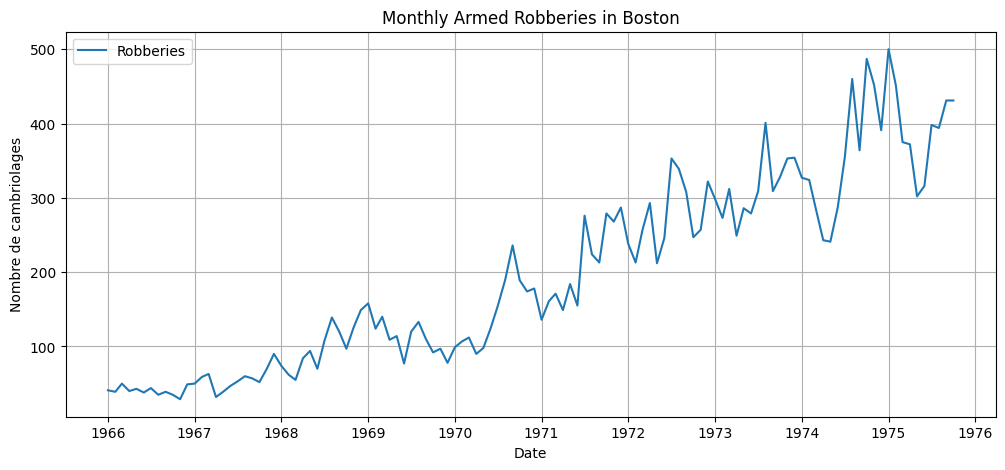

In [4]:
# ============================================================
# 2. ANALYSE EXPLORATOIRE
# ============================================================

print("\n==============================")
print("2. STATISTIQUES DESCRIPTIVES")
print("==============================")

values = series.values
N = len(values)
moyenne = np.sum(values) / N
variance = np.sum((values - moyenne) ** 2) / N
ecart_type = np.sqrt(variance)

print("Moyenne :", moyenne)
print("Variance :", variance)
print("Écart-type :", ecart_type)
print("\nAvec pandas :")
print(series.describe())

plt.figure(figsize=(12, 5))
plt.plot(series, label="Robberies")
plt.title("Monthly Armed Robberies in Boston")
plt.xlabel("Date")
plt.ylabel("Nombre de cambriolages")
plt.legend()
plt.grid()
plt.show()


On représente graphiquement la série afin d’observer son comportement dans le temps.

Cette visualisation permet de repérer :

- une tendance croissante ou décroissante ;
- des périodes de forte augmentation ;
- des fluctuations irrégulières ;
- une éventuelle saisonnalité ;
- des valeurs extrêmes.

L’interprétation graphique est importante car elle oriente le choix des transformations et des modèles.

In [5]:
#Interpréter graphiquement la tendance, la variance, la saisonnalité
print("\nInterprétation graphique :")
print("Le graphique montre une tendance haussière claire.")
print("La variance semble aussi augmenter avec le temps : les fluctuations deviennent plus grandes lorsque le niveau de la série augmente.")
print("La saisonnalité n'est pas très forte visuellement, mais certains pics peuvent apparaître à certaines périodes.")
print("La série est non stationnaire car la moyenne et la variance changent avec le temps.")
#Commenter les statistiques dans le contexte des cambriolages à Boston
print("\nInterprétation des statistiques :")
print(f"La moyenne est de {moyenne:.2f} cambriolages par mois.")
print(f"La variance est élevée ({variance:.2f}), ce qui montre une forte dispersion des valeurs.")
print(f"L'écart-type est de {ecart_type:.2f}, donc les cambriolages varient beaucoup autour de la moyenne.")
print(f"Le minimum est {series.min()} et le maximum est {series.max()}, ce qui montre une forte augmentation sur la période.")
print("Dans le contexte de Boston, cela signifie que le nombre de cambriolages armés n'est pas stable dans le temps.")


Interprétation graphique :
Le graphique montre une tendance haussière claire.
La variance semble aussi augmenter avec le temps : les fluctuations deviennent plus grandes lorsque le niveau de la série augmente.
La saisonnalité n'est pas très forte visuellement, mais certains pics peuvent apparaître à certaines périodes.
La série est non stationnaire car la moyenne et la variance changent avec le temps.

Interprétation des statistiques :
La moyenne est de 196.29 cambriolages par mois.
La variance est élevée (16256.22), ce qui montre une forte dispersion des valeurs.
L'écart-type est de 127.50, donc les cambriolages varient beaucoup autour de la moyenne.
Le minimum est 29 et le maximum est 500, ce qui montre une forte augmentation sur la période.
Dans le contexte de Boston, cela signifie que le nombre de cambriolages armés n'est pas stable dans le temps.


# 3. Décomposition additive et multiplicative

La décomposition permet de séparer la série en plusieurs composantes :

- la tendance ;
- la saisonnalité ;
- les résidus.

Deux modèles sont étudiés :

## Modèle additif

Le modèle additif suppose que les composantes s’ajoutent :

$$
Y_t = T_t + S_t + R_t
$$

Il est adapté lorsque l’amplitude des variations reste relativement constante dans le temps.

## Modèle multiplicatif

Le modèle multiplicatif suppose que les composantes se multiplient :

$$
Y_t = T_t \times S_t \times R_t
$$

Il est adapté lorsque l’amplitude des variations augmente ou diminue avec le niveau de la série.

L’objectif est de comparer les deux approches et d’interpréter la tendance, la saisonnalité et les résidus.

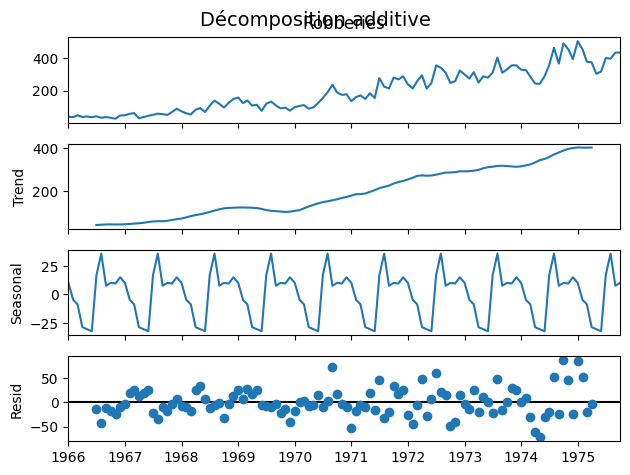

Interprétation de la décomposition ADDITIVE

1. Tendance (Trend)
La composante de tendance est clairement croissante,
ce qui indique une augmentation progressive du nombre de cambriolages au fil du temps.

2. Saisonnalité (Seasonal)
La composante saisonnière présente un motif périodique qui se répète chaque année.
L’amplitude des variations reste globalement constante dans le temps,
ce qui correspond à une saisonnalité de type additif.

3. Résidus (Resid)
Les résidus sont globalement dispersés autour de zéro,
mais leur dispersion semble légèrement augmenter avec le temps,
ce qui suggère une variance non constante.


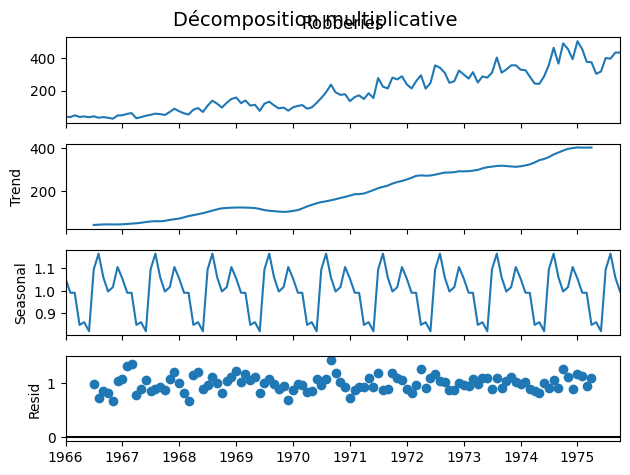

Interprétation de la décomposition MULTIPLICATIVE

1. Tendance (Trend)
La composante de tendance est clairement croissante,
indiquant une augmentation continue du nombre de cambriolages.

2. Saisonnalité (Seasonal)
La composante saisonnière montre un motif périodique qui se répète chaque année.
Contrairement au modèle additif, l’amplitude des variations dépend du niveau de la série,
ce qui est cohérent avec une saisonnalité multiplicative.

3. Résidus (Resid)
Les résidus sont mieux répartis et plus homogènes,
ce qui indique que le modèle capture mieux la structure de la série.


In [ ]:
# ============================================================
# 5. DÉCOMPOSITION ADDITIVE ET MULTIPLICATIVE
# ============================================================

decomp_add = seasonal_decompose(series, model="additive", period=12)
decomp_mul = seasonal_decompose(series, model="multiplicative", period=12)

decomp_add.plot()
plt.suptitle("Décomposition additive", fontsize=14)
plt.show()
print("Interprétation de la décomposition ADDITIVE")
print("==============================")

print("\n1. Tendance (Trend)")
print("La composante de tendance est clairement croissante,")
print("ce qui indique une augmentation progressive du nombre de cambriolages au fil du temps.")

print("\n2. Saisonnalité (Seasonal)")
print("La composante saisonnière présente un motif périodique qui se répète chaque année.")
print("L'amplitude des variations reste globalement constante dans le temps,")
print("ce qui correspond à une saisonnalité de type additif.")

print("\n3. Résidus (Resid)")
print("Les résidus sont globalement dispersés autour de zéro,")
print("mais leur dispersion semble légèrement augmenter avec le temps,")
print("ce qui suggère une variance non constante.")
decomp_mul.plot()
plt.suptitle("Décomposition multiplicative", fontsize=14)
plt.show()
print("Interprétation de la décomposition MULTIPLICATIVE")
print("==============================")

print("\n1. Tendance (Trend)")
print("La composante de tendance est clairement croissante,")
print("indiquant une augmentation continue du nombre de cambriolages.")

print("\n2. Saisonnalité (Seasonal)")
print("La composante saisonnière montre un motif périodique qui se répète chaque année.")
print("Contrairement au modèle additif, l'amplitude des variations dépend du niveau de la série,")
print("ce qui est cohérent avec une saisonnalité multiplicative.")

print("\n3. Résidus (Resid)")
print("Les résidus sont mieux répartis et plus homogènes,")
print("ce qui indique que le modèle capture mieux la structure de la série.")


À partir des visualisations précédentes, on peut formuler des hypothèses préliminaires sur la série.

On cherche notamment à savoir si :

- la série présente une tendance ;
- la variance semble constante ou non ;
- une saisonnalité est visible ;
- la série semble stationnaire ;
- une transformation est nécessaire avant modélisation.

Ces hypothèses seront ensuite vérifiées à l’aide de tests statistiques comme ADF et KPSS.

In [7]:
print("\nPremières hypothèses sur la dynamique :")
print("H1 : La série possède une tendance haussière forte.")
print("Justification : le line plot montre une augmentation du nombre de cambriolages au fil du temps.")

print("H2 : La série n'est probablement pas stationnaire.")
print("Justification : la moyenne et la variance changent avec le temps.")

print("H3 : La variance n'est pas constante.")
print("Justification : les fluctuations deviennent plus importantes dans les dernières années.")

print("H4 : Une transformation logarithmique ou Box-Cox peut être utile.")
print("Justification : ces transformations permettent de stabiliser la variance.")

print("H5 : Une différenciation sera probablement nécessaire.")
print("Justification : la tendance doit être supprimée avant d'appliquer un modèle ARIMA.")


Premières hypothèses sur la dynamique :
H1 : La série possède une tendance haussière forte.
Justification : le line plot montre une augmentation du nombre de cambriolages au fil du temps.
H2 : La série n'est probablement pas stationnaire.
Justification : la moyenne et la variance changent avec le temps.
H3 : La variance n'est pas constante.
Justification : les fluctuations deviennent plus importantes dans les dernières années.
H4 : Une transformation logarithmique ou Box-Cox peut être utile.
Justification : ces transformations permettent de stabiliser la variance.
H5 : Une différenciation sera probablement nécessaire.
Justification : la tendance doit être supprimée avant d'appliquer un modèle ARIMA.


# 4. Feature engineering

Dans cette partie, on enrichit la série avec de nouvelles variables temporelles.

On peut créer par exemple :

- des retards, appelés aussi lags ;
- des moyennes mobiles ;
- des variables liées au mois ou à l’année ;
- des transformations utiles pour l’analyse.

Ces nouvelles variables permettent de mieux comprendre les dépendances temporelles et peuvent aider à la modélisation.

In [8]:
# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================

features = data.copy()
features["Lag_1"] = features["Robberies"].shift(1)
features["Lag_2"] = features["Robberies"].shift(2)
features["Rolling_Mean_3"] = features["Robberies"].rolling(window=3).mean()
features["Rolling_Mean_6"] = features["Robberies"].rolling(window=6).mean()
features["Rolling_Std_3"] = features["Robberies"].rolling(window=3).std()
features["Month"] = features.index.month
features["Year"] = features.index.year

print("\n==============================")
print("FEATURE ENGINEERING")
print("==============================")
print(features.head(10))



FEATURE ENGINEERING
            Robberies  Lag_1  Lag_2  Rolling_Mean_3  Rolling_Mean_6  \
Months                                                                
1966-01-01         41    NaN    NaN             NaN             NaN   
1966-02-01         39   41.0    NaN             NaN             NaN   
1966-03-01         50   39.0   41.0       43.333333             NaN   
1966-04-01         40   50.0   39.0       43.000000             NaN   
1966-05-01         43   40.0   50.0       44.333333             NaN   
1966-06-01         38   43.0   40.0       40.333333       41.833333   
1966-07-01         44   38.0   43.0       41.666667       42.333333   
1966-08-01         35   44.0   38.0       39.000000       41.666667   
1966-09-01         39   35.0   44.0       39.333333       39.833333   
1966-10-01         35   39.0   35.0       36.333333       39.000000   

            Rolling_Std_3  Month  Year  
Months                                  
1966-01-01            NaN      1  1966  
196

# 5. Tests de stationnarité : ADF et KPSS

Avant d’appliquer un modèle ARIMA, il faut vérifier si la série est stationnaire.

Une série stationnaire possède généralement :

- une moyenne constante dans le temps ;
- une variance constante ;
- une autocovariance qui dépend uniquement du décalage temporel.

## Test ADF

Le test ADF, Augmented Dickey-Fuller, teste la présence d’une racine unitaire.

Hypothèses :

- $H_0$ : la série est non stationnaire ;
- $H_1$ : la série est stationnaire.

Règle de décision :

- si la p-value est inférieure à 0,05, on rejette $H_0$ ;
- sinon, on ne rejette pas $H_0$.

## Test KPSS

Le test KPSS fonctionne avec des hypothèses inverses.

Hypothèses :

- $H_0$ : la série est stationnaire ;
- $H_1$ : la série est non stationnaire.

L’utilisation conjointe de ADF et KPSS permet d’avoir une conclusion plus robuste.

In [9]:
# ============================================================
# 7. TESTS DE STATIONNARITÉ ADF ET KPSS
# ============================================================

def test_stationarity(x, name="Série"):
    print("\n==============================")
    print("TEST DE STATIONNARITÉ :", name)
    # --- Test ADF (Augmented Dickey-Fuller) -------------------------------------
    print("==============================")

    adf_result = adfuller(x.dropna())
    print("\nADF Test")
    print("H0 : la série est non stationnaire")
    print("ADF Statistic :", adf_result[0])
    print("p-value :", adf_result[1])
    
    if adf_result[1] < 0.05:
        print("Conclusion ADF : on rejette H0 => série stationnaire")
    else:
        print("Conclusion ADF : on ne rejette pas H0 => série non stationnaire")

    kpss_result = kpss(x.dropna(), regression="c", nlags="auto")
    print("\nKPSS Test")
    print("H0 : la série est stationnaire")
    print("KPSS Statistic :", kpss_result[0])
    print("p-value :", kpss_result[1])

    if kpss_result[1] < 0.05:
        print("Conclusion KPSS : on rejette H0 => série non stationnaire")
    else:
        print("Conclusion KPSS : on ne rejette pas H0 => série stationnaire")

test_stationarity(series, "Série originale")



TEST DE STATIONNARITÉ : Série originale

ADF Test
H0 : la série est non stationnaire
ADF Statistic : 1.0011021402457787
p-value : 0.994277563805723
Conclusion ADF : on ne rejette pas H0 => série non stationnaire

KPSS Test
H0 : la série est stationnaire
KPSS Statistic : 1.7118702628429108
p-value : 0.01
Conclusion KPSS : on rejette H0 => série non stationnaire


C:\Users\NITRO V15\AppData\Local\Temp\ipykernel_300612\3216882581.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(x.dropna(), regression="c", nlags="auto")


# 6. Transformations et différenciation

Si la série n’est pas stationnaire, on applique des transformations pour stabiliser sa moyenne ou sa variance.

Les transformations étudiées sont :

- la transformation logarithmique ;
- la transformation racine carrée ;
- la différenciation simple ;
- la combinaison log + différenciation ;
- éventuellement Box-Cox.

L’objectif est d’obtenir une série plus stable et plus adaptée aux modèles ARIMA.

La différenciation permet de supprimer une tendance et de rendre la série plus stationnaire.

On utilise l’opérateur de retard $L$ défini par :

$$
L Y_t = Y_{t-1}
$$

La différenciation d’ordre 1 est donnée par :

$$
\Delta Y_t = Y_t - Y_{t-1}
$$

En utilisant l’opérateur de retard :

$$
\Delta Y_t = (1 - L)Y_t
$$

Pour une différenciation d’ordre $d$ :

$$
\Delta^d Y_t = (1 - L)^dY_t
$$

Dans le code, cette opération est réalisée avec `pandas.diff()`.

In [10]:
# ============================================================
# 8. TRANSFORMATIONS
# ============================================================
# 2.3 DIFFERENCIATION (operateur de retard L)
# =============================================================================
 
data_log = np.log(series)
data_sqrt = np.sqrt(series)
data_diff = series.diff().dropna()
data_log_diff = data_log.diff().dropna()
data_boxcox, lambda_boxcox = boxcox(series)
data_boxcox = pd.Series(data_boxcox, index=series.index)

print("\nLambda Box-Cox :", lambda_boxcox)


Lambda Box-Cox : 0.3167798227232088


On compare maintenant les différentes transformations appliquées à la série.

Le but est d’observer quelle transformation permet de :

- réduire la tendance ;
- stabiliser la variance ;
- rendre la série plus proche d’une série stationnaire ;
- faciliter l’identification des modèles ARIMA.

La transformation la plus pertinente sera utilisée pour l’analyse ACF/PACF et la modélisation.

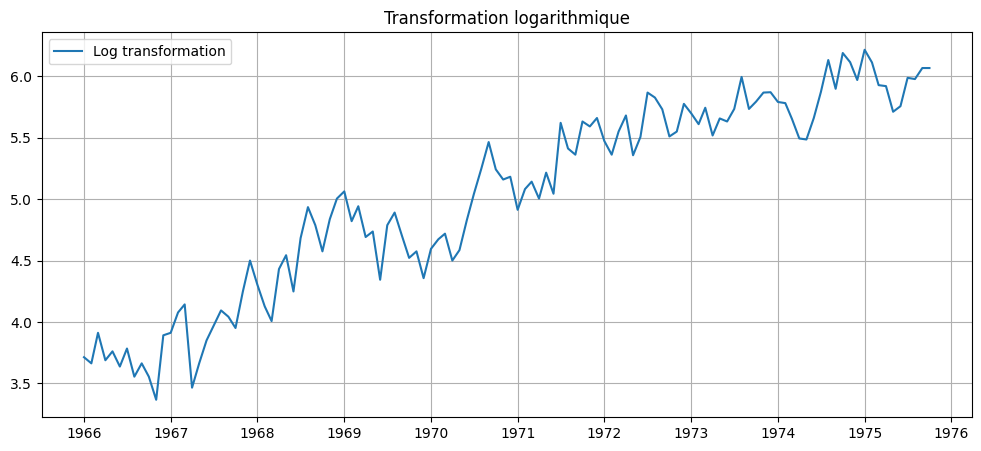

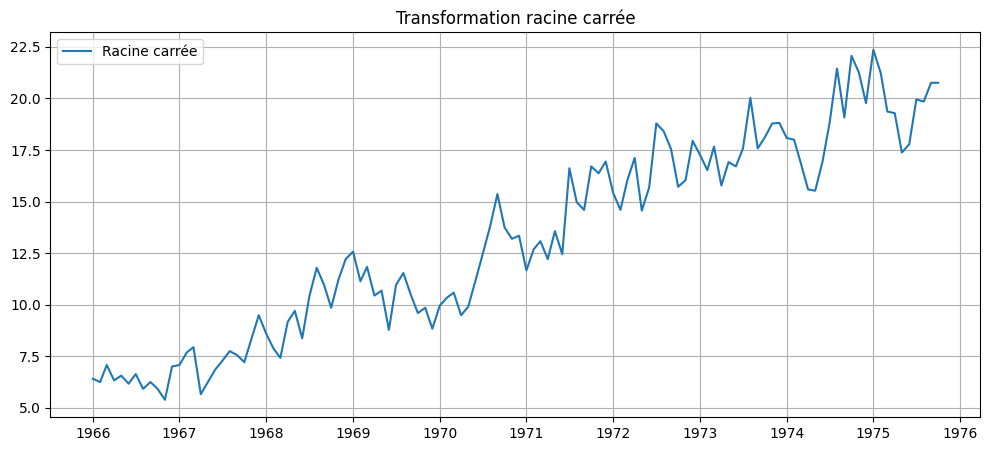

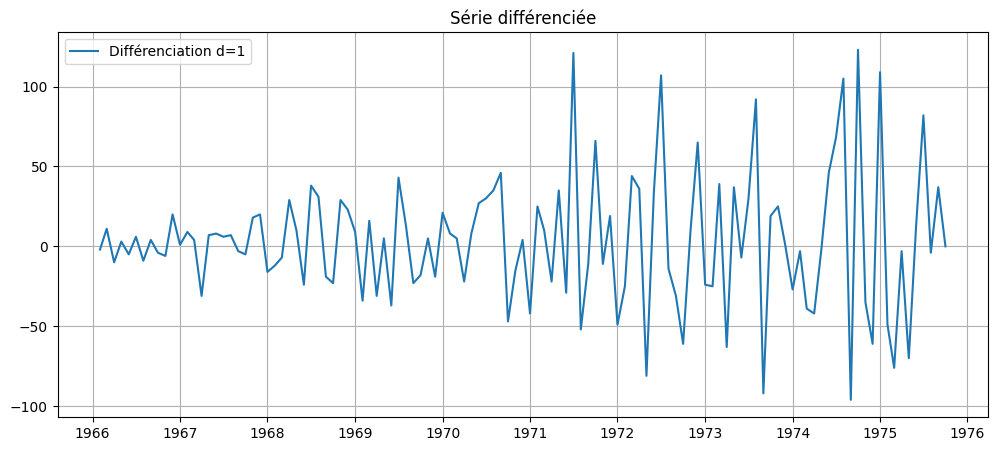

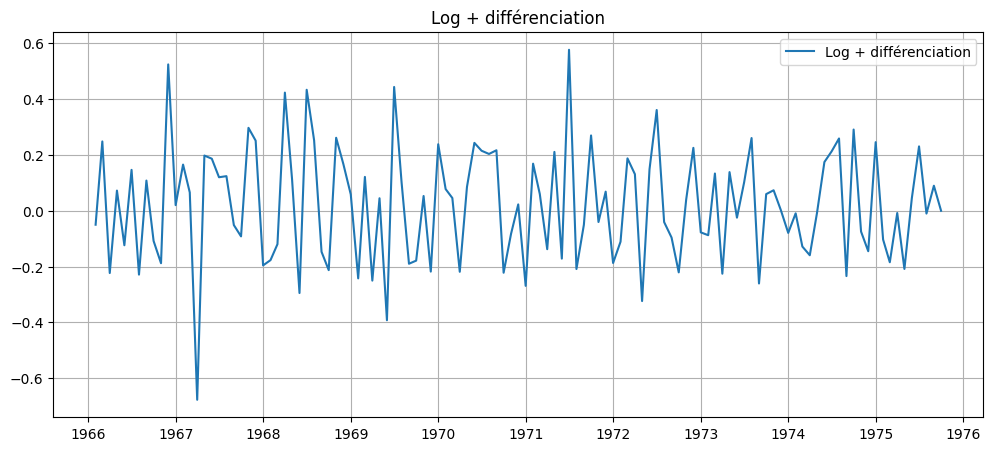

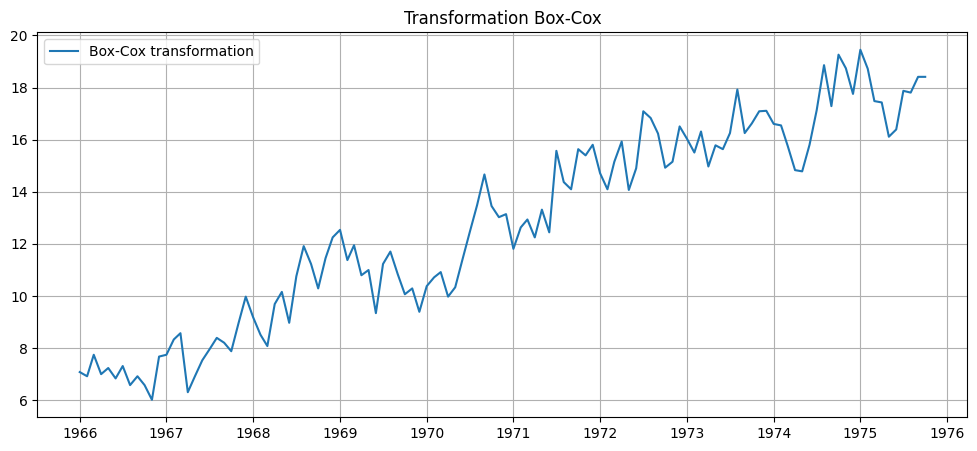


TEST DE STATIONNARITÉ : Série différenciée d=1

ADF Test
H0 : la série est non stationnaire
ADF Statistic : -7.428564475067206
p-value : 6.450795412686752e-11
Conclusion ADF : on rejette H0 => série stationnaire

KPSS Test
H0 : la série est stationnaire
KPSS Statistic : 0.13159427343273838
p-value : 0.1
Conclusion KPSS : on ne rejette pas H0 => série stationnaire

TEST DE STATIONNARITÉ : Log + différenciation

ADF Test
H0 : la série est non stationnaire
ADF Statistic : -7.601792127269039
p-value : 2.3786024417438203e-11
Conclusion ADF : on rejette H0 => série stationnaire

KPSS Test
H0 : la série est stationnaire
KPSS Statistic : 0.08973643572134667
p-value : 0.1
Conclusion KPSS : on ne rejette pas H0 => série stationnaire

Interprétation des transformations

1. Transformation logarithmique
La transformation logarithmique réduit l'amplitude des grandes valeurs.
Elle permet de stabiliser la variance lorsque celle-ci augmente avec le niveau.
Elle atténue les effets de croissance exponen

C:\Users\NITRO V15\AppData\Local\Temp\ipykernel_300612\3216882581.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(x.dropna(), regression="c", nlags="auto")
C:\Users\NITRO V15\AppData\Local\Temp\ipykernel_300612\3216882581.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(x.dropna(), regression="c", nlags="auto")


In [11]:
plt.figure(figsize=(12, 5))
plt.plot(data_log, label="Log transformation")
plt.title("Transformation logarithmique")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(data_sqrt, label="Racine carrée")
plt.title("Transformation racine carrée")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(data_diff, label="Différenciation d=1")
plt.title("Série différenciée")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(data_log_diff, label="Log + différenciation")
plt.title("Log + différenciation")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(data_boxcox, label="Box-Cox transformation")
plt.title("Transformation Box-Cox")
plt.legend()
plt.grid()
plt.show()
test_stationarity(data_diff, "Série différenciée d=1")
test_stationarity(data_log_diff, "Log + différenciation")
print("\n==============================")
print("Interprétation des transformations")
print("==============================")

# -----------------------------
# Log transformation
# -----------------------------
print("\n1. Transformation logarithmique")
print("La transformation logarithmique réduit l'amplitude des grandes valeurs.")
print("Elle permet de stabiliser la variance lorsque celle-ci augmente avec le niveau.")
print("Elle atténue les effets de croissance exponentielle.")
print("La série devient plus homogène et plus proche de la stationnarité.")

# -----------------------------
# Racine carrée
# -----------------------------
print("\n2. Transformation racine carrée")
print("La transformation racine carrée réduit également l'amplitude des valeurs élevées,")
print("mais de manière moins forte que le logarithme.")
print("Elle est utile lorsque la variance augmente modérément.")
print("Cependant, elle est généralement moins efficace que le log pour stabiliser la variance.")

# -----------------------------
# Différenciation
# -----------------------------
print("\n3. Différenciation (d = 1)")
print("La différenciation consiste à calculer la différence entre deux observations successives.")
print("Elle permet de supprimer la tendance présente dans la série.")
print("Après différenciation, la série devient plus stable autour de zéro.")
print("C'est une étape essentielle pour rendre la série stationnaire avant ARIMA.")

# -----------------------------
# Log + différenciation
# -----------------------------
print("\n4. Log + différenciation")
print("Cette combinaison permet de stabiliser la variance (grâce au log)")
print("et de supprimer la tendance (grâce à la différenciation).")
print("La série obtenue est généralement plus proche d'une série stationnaire.")
print("C'est souvent la transformation la plus adaptée pour les modèles ARIMA.")

# -----------------------------
# Box-Cox
# -----------------------------
print("\n5. Transformation Box-Cox")
print(f"La valeur de lambda estimée est : {lambda_boxcox:.3f}")
print("La transformation Box-Cox permet d'optimiser automatiquement la transformation")
print("afin de rendre la série la plus proche possible d'une distribution normale.")
print("Elle stabilise la variance et améliore la qualité de modélisation.")
print("C'est une généralisation du logarithme.")
print("\n==============================")
print("Interprétation des transformations")
print("==============================")

# -----------------------------
# Log transformation
# -----------------------------
print("\n1. Transformation logarithmique")
print("La transformation logarithmique réduit l'amplitude des grandes valeurs.")
print("Elle permet de stabiliser la variance lorsque celle-ci augmente avec le niveau.")
print("Elle atténue les effets de croissance exponentielle.")
print("La série devient plus homogène et plus proche de la stationnarité.")

# -----------------------------
# Racine carrée
# -----------------------------
print("\n2. Transformation racine carrée")
print("La transformation racine carrée réduit également l'amplitude des valeurs élevées,")
print("mais de manière moins forte que le logarithme.")
print("Elle est utile lorsque la variance augmente modérément.")
print("Cependant, elle est généralement moins efficace que le log pour stabiliser la variance.")

# -----------------------------
# Différenciation
# -----------------------------
print("\n3. Différenciation (d = 1)")
print("La différenciation consiste à calculer la différence entre deux observations successives.")
print("Elle permet de supprimer la tendance présente dans la série.")
print("Après différenciation, la série devient plus stable autour de zéro.")
print("C'est une étape essentielle pour rendre la série stationnaire avant ARIMA.")

# -----------------------------
# Log + différenciation
# -----------------------------
print("\n4. Log + différenciation")
print("Cette combinaison permet de stabiliser la variance (grâce au log)")
print("et de supprimer la tendance (grâce à la différenciation).")
print("La série obtenue est généralement plus proche d'une série stationnaire.")
print("C'est souvent la transformation la plus adaptée pour les modèles ARIMA.")

# -----------------------------
# Box-Cox
# -----------------------------
print("\n5. Transformation Box-Cox")
print(f"La valeur de lambda estimée est : {lambda_boxcox:.3f}")
print("La transformation Box-Cox permet d'optimiser automatiquement la transformation")
print("afin de rendre la série la plus proche possible d'une distribution normale.")
print("Elle stabilise la variance et améliore la qualité de modélisation.")
print("C'est une généralisation du logarithme.")


# 7. Analyse ACF et PACF

Les graphiques ACF et PACF permettent d’identifier les ordres possibles des modèles AR, MA et ARMA.

## ACF

L’autocorrélation au retard $k$ mesure la corrélation entre $Y_t$ et $Y_{t-k}$ :

$$
\rho(k) = \frac{Cov(Y_t, Y_{t-k})}{Var(Y_t)}
$$

Elle aide principalement à identifier l’ordre $q$ d’un modèle MA.

## PACF

L’autocorrélation partielle mesure la relation entre $Y_t$ et $Y_{t-k}$ après avoir retiré l’effet des retards intermédiaires.

Elle aide principalement à identifier l’ordre $p$ d’un modèle AR.

L’objectif est de formuler des hypothèses préliminaires sur les valeurs de $p$ et $q$.

<Figure size 1000x400 with 0 Axes>

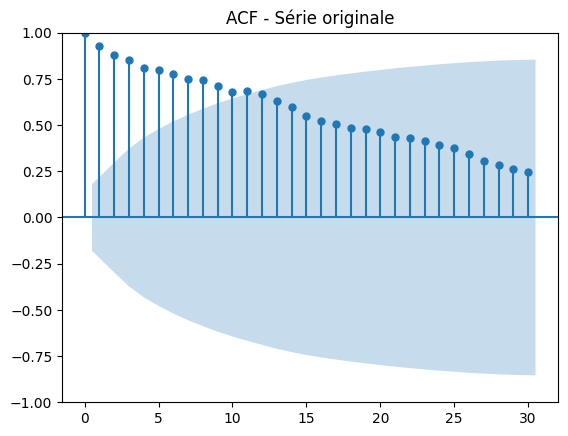

<Figure size 1000x400 with 0 Axes>

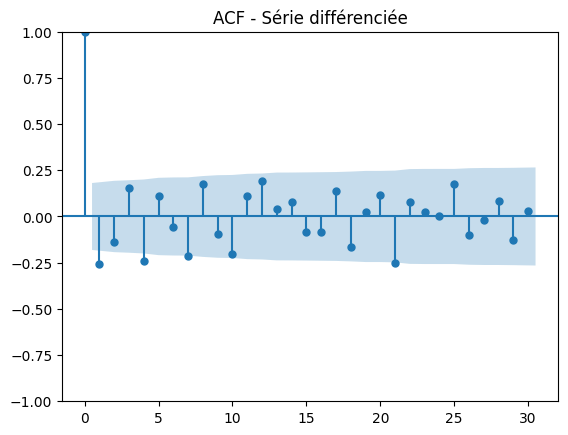

<Figure size 1000x400 with 0 Axes>

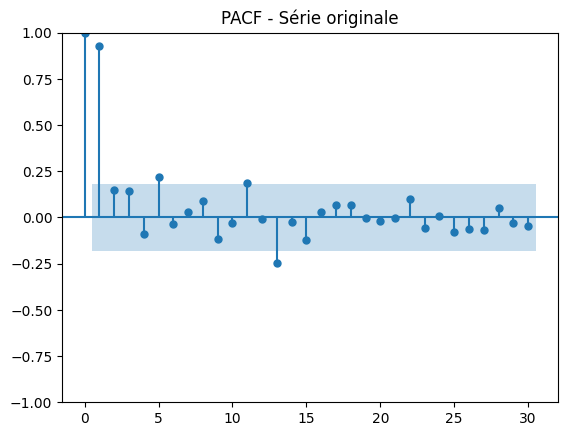

<Figure size 1000x400 with 0 Axes>

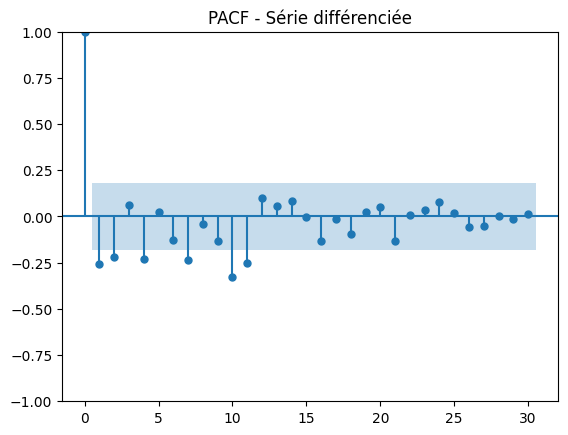


Analyse avancée ACF / PACF
ACF mesure la corrélation entre y(t) et y(t-k).
PACF mesure la corrélation directe sans effet intermédiaire.

Sur la série originale :
- ACF décroît lentement → non stationnarité.
- PACF ne présente pas de coupure nette.
=> La série contient une tendance.

Sur la série différenciée :
- ACF montre une coupure après quelques retards → suggère MA(q).
- PACF montre une coupure après quelques retards → suggère AR(p).

Hypothèses possibles :
p ≈ 1 ou 2
q ≈ 1 ou 2
d = 1 (déjà appliqué)


In [12]:
# ============================================================
# 9. ACF ET PACF
# ============================================================

plt.figure(figsize=(10, 4))
plot_acf(series, lags=30)
plt.title("ACF - Série originale")
plt.show()

plt.figure(figsize=(10, 4))
plot_acf(data_diff, lags=30)
plt.title("ACF - Série différenciée")
plt.show()

plt.figure(figsize=(10, 4))
plot_pacf(series, lags=30)
plt.title("PACF - Série originale")
plt.show()



plt.figure(figsize=(10, 4))
plot_pacf(data_diff, lags=30)
plt.title("PACF - Série différenciée")
plt.show()

print("\n==============================")
print("Analyse avancée ACF / PACF")
print("==============================")

print("ACF mesure la corrélation entre y(t) et y(t-k).")
print("PACF mesure la corrélation directe sans effet intermédiaire.")

print("\nSur la série originale :")
print("- ACF décroît lentement → non stationnarité.")
print("- PACF ne présente pas de coupure nette.")
print("=> La série contient une tendance.")

print("\nSur la série différenciée :")
print("- ACF montre une coupure après quelques retards → suggère MA(q).")
print("- PACF montre une coupure après quelques retards → suggère AR(p).")

print("\nHypothèses possibles :")
print("p ≈ 1 ou 2")
print("q ≈ 1 ou 2")
print("d = 1 (déjà appliqué)")


# 8. Découpage chronologique Train/Test

Pour une série temporelle, il ne faut pas mélanger les données aléatoirement.

Contrairement aux problèmes classiques de Machine Learning, l’ordre temporel doit être respecté afin d’éviter le data leakage.

On découpe donc la série en deux parties :

- un ensemble d’entraînement contenant les premières observations ;
- un ensemble de test contenant les observations les plus récentes.

Le modèle apprend uniquement sur le passé et il est évalué sur le futur.


TRAIN / TEST SPLIT
Train size : 94
Test size : 24


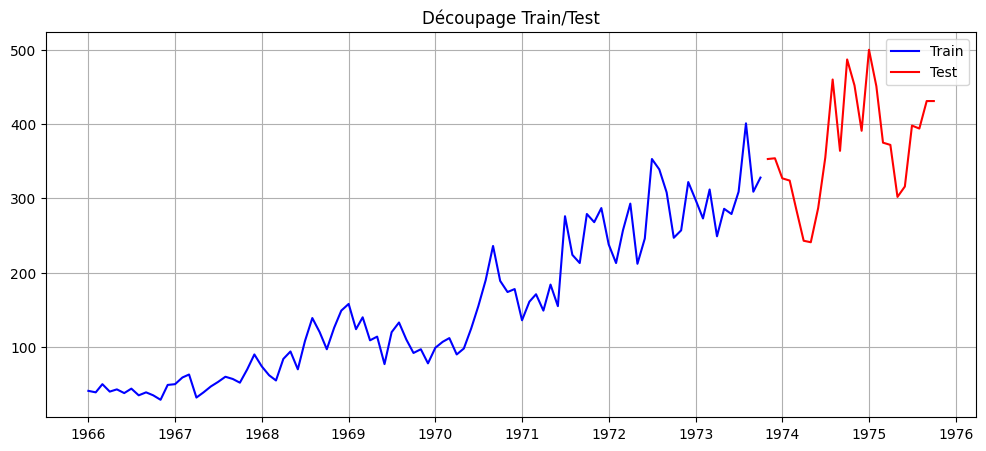

Justification du découpage chronologique
Dans une série temporelle, les observations sont dépendantes du temps.
Chaque valeur dépend des valeurs passées (dépendance temporelle).


In [13]:
# ============================================================
# 10. TRAIN / TEST SPLIT
# ============================================================

train_size = int(len(series) * 0.8)

train = series.iloc[:train_size]
test = series.iloc[train_size:]

print("\n==============================")
print("TRAIN / TEST SPLIT")
print("==============================")
print("Train size :", len(train))
print("Test size :", len(test))

plt.figure(figsize=(12, 5))
plt.plot(train, label="Train", color="blue")
plt.plot(test, label="Test", color="red")
plt.title("Découpage Train/Test")
plt.legend()
plt.grid()
plt.show()

print("Justification du découpage chronologique")
print("==============================")

print("Dans une série temporelle, les observations sont dépendantes du temps.")
print("Chaque valeur dépend des valeurs passées (dépendance temporelle).")


# 9. Métriques d’évaluation manuelles

Dans cette partie, on implémente manuellement les métriques d’évaluation avec `numpy`.

Les métriques utilisées sont :

## MSE

Le Mean Squared Error mesure l’erreur quadratique moyenne :

$$
MSE = \frac{1}{n}\sum_{t=1}^{n}(y_t - \hat{y}_t)^2
$$

## RMSE

Le Root Mean Squared Error est la racine carrée du MSE :

$$
RMSE = \sqrt{MSE}
$$

Il s’interprète dans la même unité que la série, c’est-à-dire le nombre de braquages.

## MAE

Le Mean Absolute Error mesure l’erreur absolue moyenne :

$$
MAE = \frac{1}{n}\sum_{t=1}^{n}|y_t - \hat{y}_t|
$$

Ces métriques permettent de comparer objectivement les modèles.

In [14]:
# ============================================================
# 11. MÉTRIQUES MANUELLES
# ============================================================

def mse_manual(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean((y_true - y_pred) ** 2)

def rmse_manual(y_true, y_pred):
    return np.sqrt(mse_manual(y_true, y_pred))

def mae_manual(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs(y_true - y_pred))

# 10. Baseline naïve

Le modèle naïf est le modèle de référence le plus simple.

Il suppose que la valeur future est égale à la dernière valeur observée :

$$
\hat{Y}_{t+1} = Y_t
$$

Ce modèle est important car tout modèle avancé doit au minimum être capable de faire mieux que cette référence simple.

Il permet de vérifier si les modèles ARIMA apportent réellement une amélioration.

In [15]:
# ============================================================
# 12. BASELINE NAÏVE
# ============================================================

history = list(train.values)
pred_naive = []

for i in range(len(test)):
    yhat = history[-1]
    pred_naive.append(yhat)
    history.append(test.iloc[i])

rmse_naive = rmse_manual(test, pred_naive)
mae_naive = mae_manual(test, pred_naive)

print("\n==============================")
print("BASELINE NAÏVE")
print("==============================")
print("RMSE :", rmse_naive)
print("MAE :", mae_naive)

print("\nInterprétation du modèle naïf :")
print("Le modèle naïf prédit que la valeur future est égale à la dernière observation connue.")
print("Autrement dit : y(t) = y(t-1).")

print("\nComportement :")
print("- Le modèle suit directement la dernière valeur observée.")
print("- Il fonctionne bien lorsque la série est stable ou peu variable.")
print("- Il réagit rapidement aux changements brusques.")

print("\nLimites :")
print("- Il ne prend pas en compte la tendance globale.")
print("- Il ignore la saisonnalité.")
print("- Il ne capture aucune structure complexe de la série.")
print("- Il peut produire de mauvaises prédictions si la série évolue rapidement.")

#print("Interprétation des métriques'BASELINE NAÏVE)")
print("==============================")
print("MSE : pénalise fortement les grandes erreurs (au carré).")
print("RMSE : s'exprime dans la même unité que la variable étudiée (nombre de cambriolages).")
print("MAE : représente l'erreur moyenne absolue en nombre de cambriolages.")
print("\nInterprétation dans le contexte :")
print("Si RMSE =",rmse_naive,", cela signifie que l'erreur moyenne est d'environ ",rmse_naive," cambriolages par mois.")
print("Si MAE = ",mae_naive,", cela signifie qu'en moyenne, le modèle se trompe de ",mae_naive," cambriolages.")



BASELINE NAÏVE
RMSE : 59.505251869057744
MAE : 46.541666666666664

Interprétation du modèle naïf :
Le modèle naïf prédit que la valeur future est égale à la dernière observation connue.
Autrement dit : y(t) = y(t-1).

Comportement :
- Le modèle suit directement la dernière valeur observée.
- Il fonctionne bien lorsque la série est stable ou peu variable.
- Il réagit rapidement aux changements brusques.

Limites :
- Il ne prend pas en compte la tendance globale.
- Il ignore la saisonnalité.
- Il ne capture aucune structure complexe de la série.
- Il peut produire de mauvaises prédictions si la série évolue rapidement.
MSE : pénalise fortement les grandes erreurs (au carré).
RMSE : s'exprime dans la même unité que la variable étudiée (nombre de cambriolages).
MAE : représente l'erreur moyenne absolue en nombre de cambriolages.

Interprétation dans le contexte :
Si RMSE = 59.505251869057744 , cela signifie que l'erreur moyenne est d'environ  59.505251869057744  cambriolages par mois.
Si 

# 11. Baseline moyenne mobile

Le modèle de moyenne mobile prédit la prochaine valeur à partir de la moyenne des $k$ dernières observations.

La formule est :

$$
\hat{Y}_{t+1} = \frac{1}{k}\sum_{i=0}^{k-1}Y_{t-i}
$$

Dans ce projet, on utilise une fenêtre mobile, par exemple $k = 12$, pour tenir compte d’une année complète de données mensuelles.

Ce modèle est plus stable que le modèle naïf, mais il peut être moins réactif aux changements brusques.


BASELINE MOYENNE MOBILE
RMSE : 63.054356327313755
MAE : 50.97222222222222


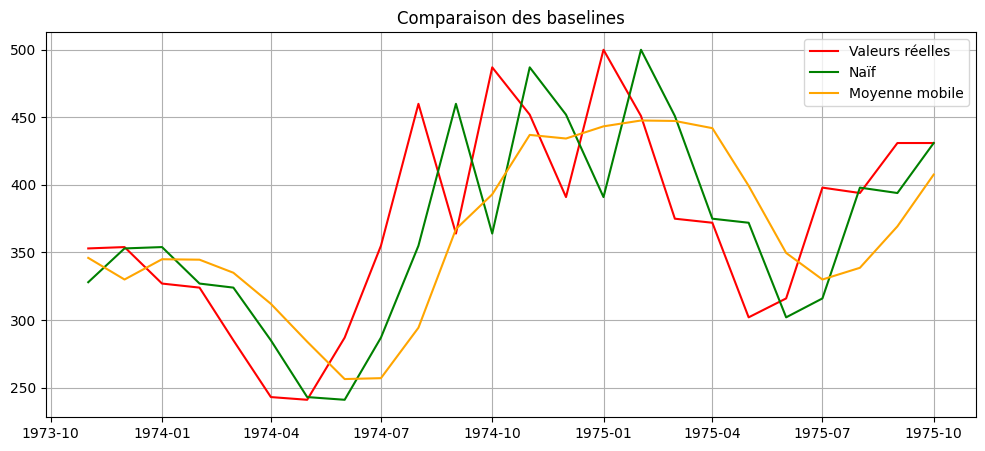


Interprétation du modèle moyenne mobile :
Le modèle moyenne mobile prédit la valeur future comme la moyenne des dernières observations.
Formule : yhat(t) = moyenne des k dernières valeurs.

Comportement :
- Le modèle lisse les fluctuations de la série.
- Il réduit l'effet du bruit.
- Il est plus stable que le modèle naïf.

Limites :
- Il réagit lentement aux changements brusques.
- Il peut retarder les tendances importantes.
- Il ne capture pas explicitement la saisonnalité.
- Le choix de la fenêtre (k) influence fortement les résultats.
Si RMSE = 63.054356327313755 , cela signifie que l'erreur moyenne est d'environ  63.054356327313755  cambriolages par mois.
Si MAE =  50.97222222222222 , cela signifie qu'en moyenne, le modèle se trompe de  50.97222222222222  cambriolages.
Walk-forward validation

Walk-forward validation
RMSE Walk-forward : 59.505251869057744
MAE Walk-forward : 46.541666666666664

Interprétation Walk-forward :
Le modèle est réentraîné à chaque nouvelle observation.
À 

In [16]:
# ============================================================
# 13. BASELINE MOYENNE MOBILE
# ============================================================

window = 3
history = list(train.values)
pred_moving_avg = []

for i in range(len(test)):
    yhat = np.mean(history[-window:])
    pred_moving_avg.append(yhat)
    history.append(test.iloc[i])

rmse_moving = rmse_manual(test, pred_moving_avg)
mae_moving = mae_manual(test, pred_moving_avg)

print("\n==============================")
print("BASELINE MOYENNE MOBILE")
print("==============================")
print("RMSE :", rmse_moving)
print("MAE :", mae_moving)

plt.figure(figsize=(12, 5))
plt.plot(test.index, test.values, label="Valeurs réelles", color="red")
plt.plot(test.index, pred_naive, label="Naïf", color="green")
plt.plot(test.index, pred_moving_avg, label="Moyenne mobile", color="orange")
plt.title("Comparaison des baselines")
plt.legend()
plt.grid()
plt.show()
print("\nInterprétation du modèle moyenne mobile :")

print("Le modèle moyenne mobile prédit la valeur future comme la moyenne des dernières observations.")
print("Formule : yhat(t) = moyenne des k dernières valeurs.")

print("\nComportement :")
print("- Le modèle lisse les fluctuations de la série.")
print("- Il réduit l'effet du bruit.")
print("- Il est plus stable que le modèle naïf.")

print("\nLimites :")
print("- Il réagit lentement aux changements brusques.")
print("- Il peut retarder les tendances importantes.")
print("- Il ne capture pas explicitement la saisonnalité.")
print("- Le choix de la fenêtre (k) influence fortement les résultats.")

print("Si RMSE =",rmse_moving,", cela signifie que l'erreur moyenne est d'environ ",rmse_moving," cambriolages par mois.")
print("Si MAE = ",mae_moving,", cela signifie qu'en moyenne, le modèle se trompe de ",mae_moving," cambriolages.")

print("Walk-forward validation")
print("\n==============================")
print("Walk-forward validation")
print("==============================")
history = list(train.values)
predictions = []
for t in range(len(test)):
    yhat = history[-1]  
    predictions.append(yhat)
    history.append(test.iloc[t])
rmse_walk = rmse_manual(test, predictions)
mae_walk = mae_manual(test, predictions)
print("RMSE Walk-forward :", rmse_walk)
print("MAE Walk-forward :", mae_walk)
print("\nInterprétation Walk-forward :")
print("Le modèle est réentraîné à chaque nouvelle observation.")
print("À chaque étape :")
print("- On prédit la prochaine valeur.")
print("- On ajoute la vraie valeur dans l'historique.")
print("- On recommence.")
print("\nAvantage :")
print("Cette méthode simule une situation réelle de prévision.")
print("Elle respecte la dépendance temporelle.")
print("\nConclusion :")
print("La walk-forward validation donne une estimation réaliste des performances du modèle.")

# ============================================================
print("\n==============================")
print("Risques en modélisation")
print("==============================")
print("\n1. Data Leakage (fuite d'information)")
print("C'est lorsque le modèle utilise des informations du futur pour prédire le passé.")
print("Exemple : mélanger aléatoirement les données.")
print("Conséquence : résultats irréalistes.")
print("\nComment éviter :")
print("- Respecter l'ordre chronologique.")
print("- Utiliser train/test correctement.")
print("- Utiliser la walk-forward validation.")
print("\n2. Surapprentissage (Overfitting)")
print("Le modèle s'adapte trop aux données d'entraînement.")
print("Il apprend le bruit au lieu de la vraie structure.")
print("\nConséquence :")
print("Bonne performance sur train, mauvaise sur test.")
print("\nComment détecter :")
print("- RMSE train << RMSE test")
print("- Résidus non aléatoires")
print("\nComment éviter :")
print("- Utiliser AIC/BIC")
print("- Simplifier le modèle")
print("- Valider avec walk-forward")


Les modèles de référence servent de point de comparaison.

Avant de choisir un modèle complexe comme ARIMA ou SARIMA, il faut vérifier qu’il améliore réellement les performances par rapport à des méthodes simples.

Si un modèle avancé ne bat pas les baselines, alors sa complexité n’est pas justifiée.

Les baselines permettent donc d’évaluer le gain réel apporté par la modélisation statistique.

# 12. Théorie des modèles AR, MA et ARMA

Dans cette partie, on étudie les modèles classiques de séries temporelles :

- AR(p) : modèle autorégressif ;
- MA(q) : modèle à moyenne mobile sur les erreurs ;
- ARMA(p,q) : combinaison des deux.

Ces modèles sont d’abord présentés théoriquement, puis implémentés manuellement from scratch, avant d’être comparés avec les résultats de `statsmodels`.

In [17]:
# ============================================================
# 14. AR(p), MA(q), ARMA(p,q)
# ============================================================

models_results = []

def evaluate_model(name, y_true, y_pred, model=None):
    rmse = rmse_manual(y_true, y_pred)
    mae = mae_manual(y_true, y_pred)
    mse = mse_manual(y_true, y_pred)

    aic = model.aic if model is not None else np.nan
    bic = model.bic if model is not None else np.nan

    models_results.append({
        "Modèle": name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "AIC": aic,
        "BIC": bic
    })

    print("\n==============================")
    print(name)
    print("==============================")
    print("MSE  :", mse)
    print("RMSE :", rmse)
    print("MAE  :", mae)
    print("AIC  :", aic)
    print("BIC  :", bic)


evaluate_model("Naïf", test, pred_naive)
evaluate_model("Moyenne mobile", test, pred_moving_avg)



Naïf
MSE  : 3540.875
RMSE : 59.505251869057744
MAE  : 46.541666666666664
AIC  : nan
BIC  : nan

Moyenne mobile
MSE  : 3975.8518518518517
RMSE : 63.054356327313755
MAE  : 50.97222222222222
AIC  : nan
BIC  : nan


# 13. Modèle AR(p) from scratch par OLS

Un modèle AR(p) exprime la valeur actuelle comme une combinaison linéaire de ses $p$ valeurs passées :

$$
Y_t = c + \phi_1Y_{t-1} + \phi_2Y_{t-2} + ... + \phi_pY_{t-p} + \varepsilon_t
$$

En utilisant l’opérateur de retard :

$$
\Phi(L)Y_t = c + \varepsilon_t
$$

avec :

$$
\Phi(L) = 1 - \phi_1L - \phi_2L^2 - ... - \phi_pL^p
$$

Dans cette implémentation, on construit une matrice de design contenant les retards de la série, puis on estime les paramètres par moindres carrés ordinaires :

$$
\hat{\beta} = (X'X)^{-1}X'Y
$$

In [18]:
# ============================================================
# 14.1 AR(p) FROM SCRATCH : MATRICE DE DESIGN + OLS
# ============================================================

def ar_from_scratch_ols(series, p=1):
    y = np.array(series)
    X = []
    Y = []
    for t in range(p, len(y)):
        X.append(y[t-p:t][::-1])
        Y.append(y[t])
    X = np.array(X)
    Y = np.array(Y)

    X = np.column_stack([np.ones(len(X)), X])

    # Formule OLS : beta = (X'X)^(-1) X'Y
    beta = np.linalg.inv(X.T @ X) @ X.T @ Y

    return beta

beta_ar_scratch = ar_from_scratch_ols(train, p=1)

print("\n==============================")
print("AR(1) FROM SCRATCH - OLS")
print("==============================")
print("Constante c :", beta_ar_scratch[0])
print("Coefficient phi_1 :", beta_ar_scratch[1])

print("\nInterprétation AR from scratch :")
print("Le coefficient phi_1 mesure l'influence de la valeur précédente sur la valeur actuelle.")
print("Si phi_1 est positif, une valeur élevée au mois précédent favorise une valeur élevée au mois actuel.")
print("Si phi_1 est proche de 1, la série possède une forte mémoire temporelle.")
print("Cette méthode utilise la formule OLS : beta = (X'X)^(-1)X'Y.")



AR(1) FROM SCRATCH - OLS
Constante c : 11.3152879300149
Coefficient phi_1 : 0.9451028062914151

Interprétation AR from scratch :
Le coefficient phi_1 mesure l'influence de la valeur précédente sur la valeur actuelle.
Si phi_1 est positif, une valeur élevée au mois précédent favorise une valeur élevée au mois actuel.
Si phi_1 est proche de 1, la série possède une forte mémoire temporelle.
Cette méthode utilise la formule OLS : beta = (X'X)^(-1)X'Y.


# 14. Modèle AR(p) avec statsmodels

Après l’implémentation manuelle du modèle AR(p), on estime le même modèle avec `statsmodels`.

Cette comparaison permet de vérifier :

- si les coefficients estimés manuellement sont proches de ceux de la librairie ;
- si l’implémentation from scratch est correcte ;
- si les résultats sont cohérents statistiquement.

Cette étape permet d’ouvrir la boîte noire du modèle AR.

In [19]:
# ============================================================
# 14.2 AR(p) AVEC STATSMODELS
# ============================================================

model_ar = ARIMA(train, order=(1, 0, 0)).fit()
pred_ar = model_ar.forecast(steps=len(test))
evaluate_model("AR(1) statsmodels", test, pred_ar, model_ar)

print("\nRésumé AR(1) statsmodels")
print(model_ar.summary())

print("\nComparaison AR(1) from scratch vs statsmodels :")
print("AR from scratch :")
print("c =", beta_ar_scratch[0], ", phi_1 =", beta_ar_scratch[1])
print("\nAR statsmodels :")
print(model_ar.params)

print("\nInterprétation comparaison AR :")
print("Les paramètres peuvent être légèrement différents.")
print("La version from scratch utilise OLS.")
print("Statsmodels utilise une estimation plus avancée basée sur la vraisemblance.")
print("Mais les deux méthodes cherchent à mesurer la mémoire de la série via phi.")



AR(1) statsmodels
MSE  : 22881.12564992912
RMSE : 151.26508404099448
MAE  : 126.37693024261351
AIC  : 940.8095980374691
BIC  : 948.4394823842791

Résumé AR(1) statsmodels
                               SARIMAX Results                                
Dep. Variable:              Robberies   No. Observations:                   94
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -467.405
Date:                Tue, 05 May 2026   AIC                            940.810
Time:                        03:35:18   BIC                            948.439
Sample:                    01-01-1966   HQIC                           943.892
                         - 10-01-1973                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        160.6923     64.342      

# 15. Modèle MA(q) from scratch

Un modèle MA(q) exprime la valeur actuelle comme une combinaison des erreurs passées :

$$
Y_t = \mu + \varepsilon_t + \theta_1\varepsilon_{t-1} + ... + \theta_q\varepsilon_{t-q}
$$

En opérateur de retard :

$$
Y_t = \mu + \Theta(L)\varepsilon_t
$$

avec :

$$
\Theta(L) = 1 + \theta_1L + ... + \theta_qL^q
$$

Contrairement au modèle AR, les erreurs passées ne sont pas directement observables.  
Il faut donc les estimer de manière itérative.

Dans cette partie, on utilise une optimisation numérique pour trouver les paramètres qui minimisent l’erreur du modèle.

In [20]:
# ============================================================
# 14.3 MA(q) FROM SCRATCH : ESTIMATION ITÉRATIVE DES RÉSIDUS
# ============================================================

def ma1_from_scratch(series, theta_grid=np.linspace(-0.9, 0.9, 181)):
    y = np.array(series)
    mu = np.mean(y)

    best_theta = None
    best_sse = np.inf
    best_resid = None

    for theta in theta_grid:
        resid = np.zeros(len(y))

        for t in range(1, len(y)):
            # Modèle MA(1) :
            # y_t = mu + e_t + theta * e_{t-1}
            # donc e_t = y_t - mu - theta * e_{t-1}
            resid[t] = y[t] - mu - theta * resid[t-1]

        sse = np.sum(resid ** 2)

        if sse < best_sse:
            best_sse = sse
            best_theta = theta
            best_resid = resid

    return mu, best_theta, best_sse, best_resid

mu_ma_scratch, theta_ma_scratch, sse_ma_scratch, resid_ma_scratch = ma1_from_scratch(train)

print("\n==============================")
print("MA(1) FROM SCRATCH")
print("==============================")
print("Moyenne mu :", mu_ma_scratch)
print("Coefficient theta_1 :", theta_ma_scratch)
print("SSE :", sse_ma_scratch)

print("\nInterprétation MA from scratch :")
print("Le coefficient theta_1 mesure l'effet du choc précédent sur la valeur actuelle.")
print("Si theta_1 est positif, une erreur positive passée augmente la valeur actuelle.")
print("Si theta_1 est négatif, une erreur positive passée est corrigée au mois suivant.")
print("L'estimation est itérative car les erreurs passées ne sont pas observées directement.")



MA(1) FROM SCRATCH
Moyenne mu : 151.79787234042553
Coefficient theta_1 : 0.7999999999999999
SSE : 358262.06156736135

Interprétation MA from scratch :
Le coefficient theta_1 mesure l'effet du choc précédent sur la valeur actuelle.
Si theta_1 est positif, une erreur positive passée augmente la valeur actuelle.
Si theta_1 est négatif, une erreur positive passée est corrigée au mois suivant.
L'estimation est itérative car les erreurs passées ne sont pas observées directement.


# 16. Modèle MA(q) avec statsmodels

On estime maintenant le modèle MA(q) avec `statsmodels`.

L’objectif est de comparer les paramètres obtenus avec ceux de l’implémentation from scratch.

Cette comparaison permet d’évaluer la qualité de l’optimisation manuelle et de vérifier si les coefficients estimés sont cohérents.

In [21]:
# ============================================================
# 14.4 MA(q) AVEC STATSMODELS
# ============================================================

model_ma = ARIMA(train, order=(0, 0, 1)).fit()
pred_ma = model_ma.forecast(steps=len(test))
evaluate_model("MA(1) statsmodels", test, pred_ma, model_ma)

print("\nRésumé MA(1) statsmodels")
print(model_ma.summary())

print("\nComparaison MA(1) from scratch vs statsmodels :")
print("MA from scratch theta_1 :", theta_ma_scratch)
print("\nMA statsmodels :")
print(model_ma.params)

print("\nInterprétation comparaison MA :")
print("La version from scratch teste plusieurs valeurs possibles de theta.")
print("Statsmodels utilise une optimisation numérique plus précise.")
print("Les deux méthodes cherchent à estimer l'effet des chocs passés.")

model_ma6 = ARIMA(train, order=(0, 0, 6)).fit()
pred_ma6 = model_ma6.forecast(steps=len(test))
evaluate_model("MA(6)", test, pred_ma6, model_ma6)

print("\nInterprétation MA(6) :")
print("q=6 signifie que la valeur actuelle dépend des 6 dernières erreurs.")
print("Le modèle capture les chocs passés sur 6 périodes.")
print("Si RMSE est élevé, cela signifie que les erreurs seules ne suffisent pas à expliquer la série.")



MA(1) statsmodels
MSE  : 51161.718145234976
RMSE : 226.18956241443806
MAE  : 213.20377073219365
AIC  : 1046.7091811592484
BIC  : 1054.3390655060584

Résumé MA(1) statsmodels
                               SARIMAX Results                                
Dep. Variable:              Robberies   No. Observations:                   94
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -520.355
Date:                Tue, 05 May 2026   AIC                           1046.709
Time:                        03:35:37   BIC                           1054.339
Sample:                    01-01-1966   HQIC                          1049.791
                         - 10-01-1973                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.5792     14.035   

c:\Users\NITRO V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# 17. Modèle ARMA(p,q) from scratch

Le modèle ARMA(p,q) combine une partie autorégressive AR(p) et une partie moyenne mobile MA(q).

Sa forme générale est :

$$
Y_t = c + \phi_1Y_{t-1} + ... + \phi_pY_{t-p}
+ \varepsilon_t + \theta_1\varepsilon_{t-1} + ... + \theta_q\varepsilon_{t-q}
$$

En opérateur de retard :

$$
\Phi(L)Y_t = c + \Theta(L)\varepsilon_t
$$

Ce modèle est adapté aux séries stationnaires présentant à la fois une dépendance aux valeurs passées et aux erreurs passées.

Dans cette partie, on combine les deux mécanismes AR et MA dans une implémentation manuelle.

In [22]:
# ============================================================
# 14.5 ARMA(p,q) FROM SCRATCH : COMBINAISON AR + MA
# ============================================================

def arma11_from_scratch(series,
                        phi_grid=np.linspace(-0.9, 0.9, 37),
                        theta_grid=np.linspace(-0.9, 0.9, 37)):
    y = np.array(series)
    mu = np.mean(y)

    best_phi = None
    best_theta = None
    best_sse = np.inf
    best_resid = None

    for phi in phi_grid:
        for theta in theta_grid:
            resid = np.zeros(len(y))

            for t in range(1, len(y)):
                # Modèle ARMA(1,1) :
                # y_t = mu + phi*y_{t-1} + e_t + theta*e_{t-1}
                # donc e_t = y_t - mu - phi*y_{t-1} - theta*e_{t-1}
                resid[t] = y[t] - mu - phi * y[t-1] - theta * resid[t-1]

            sse = np.sum(resid ** 2)

            if sse < best_sse:
                best_sse = sse
                best_phi = phi
                best_theta = theta
                best_resid = resid

    return mu, best_phi, best_theta, best_sse, best_resid

mu_arma_scratch, phi_arma_scratch, theta_arma_scratch, sse_arma_scratch, resid_arma_scratch = arma11_from_scratch(train)

print("\n==============================")
print("ARMA(1,1) FROM SCRATCH")
print("==============================")
print("Moyenne mu :", mu_arma_scratch)
print("Coefficient phi_1 :", phi_arma_scratch)
print("Coefficient theta_1 :", theta_arma_scratch)
print("SSE :", sse_arma_scratch)

print("\nInterprétation ARMA from scratch :")
print("ARMA combine deux mécanismes :")
print("- phi_1 : mémoire des valeurs passées.")
print("- theta_1 : mémoire des erreurs passées.")
print("Ce modèle est plus riche que AR seul ou MA seul.")
print("Mais il est adapté surtout aux séries stationnaires.")



ARMA(1,1) FROM SCRATCH
Moyenne mu : 151.79787234042553
Coefficient phi_1 : 0.20000000000000007
Coefficient theta_1 : 0.7500000000000001
SSE : 311253.6880747835

Interprétation ARMA from scratch :
ARMA combine deux mécanismes :
- phi_1 : mémoire des valeurs passées.
- theta_1 : mémoire des erreurs passées.
Ce modèle est plus riche que AR seul ou MA seul.
Mais il est adapté surtout aux séries stationnaires.


# 18. Modèle ARMA(p,q) avec statsmodels

Après avoir implémenté ARMA(p,q) manuellement, on estime le même type de modèle avec `statsmodels`.

Cette étape permet de comparer :

- les paramètres autorégressifs $\phi$ ;
- les paramètres de moyenne mobile $\theta$ ;
- la qualité de l’ajustement ;
- les erreurs de prévision.

Cette comparaison permet de valider l’approche from scratch.

In [23]:
# ============================================================
# 14.6 ARMA(p,q) AVEC STATSMODELS
# ============================================================

model_arma = ARIMA(train, order=(1, 0, 1)).fit()
pred_arma = model_arma.forecast(steps=len(test))
evaluate_model("ARMA(1,1) statsmodels", test, pred_arma, model_arma)

print("\nRésumé ARMA(1,1) statsmodels")
print(model_arma.summary())

print("\nComparaison ARMA(1,1) from scratch vs statsmodels :")
print("ARMA from scratch phi_1 :", phi_arma_scratch)
print("ARMA from scratch theta_1 :", theta_arma_scratch)
print("\nARMA statsmodels :")
print(model_arma.params)

print("\nInterprétation comparaison ARMA :")
print("La version from scratch est pédagogique et approximative.")
print("Statsmodels est plus robuste car il optimise directement la vraisemblance.")
print("La comparaison permet de comprendre le rôle des paramètres phi et theta.")

model_arma_16 = ARIMA(train, order=(1, 0, 6)).fit()
pred_arma_16 = model_arma_16.forecast(steps=len(test))
evaluate_model("ARMA(1,6)", test, pred_arma_16, model_arma_16)

print("\nInterprétation ARMA(1,6) :")
print("p=1 → dépendance avec la valeur précédente.")
print("q=6 → dépendance avec les 6 dernières erreurs.")
print("Ce modèle combine mémoire + chocs.")
print("S'il améliore RMSE → la série dépend à la fois du passé et des erreurs.")

model_arma_34 = ARIMA(train, order=(3, 0, 4)).fit()
pred_arma_34 = model_arma_34.forecast(steps=len(test))
evaluate_model("ARMA(3,4)", test, pred_arma_34, model_arma_34)

print("\nInterprétation ARMA(3,4) :")
print("p=3 → dépendance sur 3 valeurs passées.")
print("q=4 → dépendance sur 4 erreurs passées.")
print("Ce modèle est plus complexe.")
print("Il peut mieux capturer la dynamique mais risque de surapprentissage.")



ARMA(1,1) statsmodels
MSE  : 9656.25221917713
RMSE : 98.26623132682523
MAE  : 80.06113427271531
AIC  : 931.4105019595582
BIC  : 941.5836810886383

Résumé ARMA(1,1) statsmodels
                               SARIMAX Results                                
Dep. Variable:              Robberies   No. Observations:                   94
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -461.705
Date:                Tue, 05 May 2026   AIC                            931.411
Time:                        03:35:52   BIC                            941.584
Sample:                    01-01-1966   HQIC                           935.520
                         - 10-01-1973                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        151.8562    140.809 

c:\Users\NITRO V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# 19. Interprétation des paramètres AR, MA et ARMA

Les paramètres des modèles AR, MA et ARMA donnent des informations sur la dynamique de la série.

## Paramètres AR

Les coefficients $\phi$ indiquent l’influence des valeurs passées sur la valeur actuelle.

Un coefficient AR élevé signifie que les braquages passés influencent fortement les braquages actuels.

## Paramètres MA

Les coefficients $\theta$ indiquent l’influence des chocs passés ou erreurs passées.

Un coefficient MA significatif montre que les erreurs de prévision passées contiennent encore de l’information utile.

L’interprétation des paramètres permet de mieux comprendre la mémoire temporelle du phénomène étudié.

In [24]:
# ============================================================
# 14.7 INTERPRÉTATION GÉNÉRALE DES PARAMÈTRES
# ============================================================

print("\n==============================")
print("Interprétation générale des paramètres φ et θ")
print("==============================")

print("φ (phi) représente la mémoire de la série.")
print("Un φ positif signifie que les valeurs élevées ont tendance à être suivies par des valeurs élevées.")
print("Un φ proche de 1 signifie une forte persistance temporelle.")
print("Dans le contexte des cambriolages, cela veut dire que le nombre de cambriolages d'un mois dépend fortement des mois précédents.")

print("\nθ (theta) représente l'effet des chocs passés.")
print("Un θ positif signifie qu'un choc positif passé augmente encore la valeur actuelle.")
print("Un θ négatif signifie qu'un choc positif passé est corrigé dans la période suivante.")
print("Dans le contexte des cambriolages, cela peut représenter des événements imprévus qui influencent temporairement la série.")



Interprétation générale des paramètres φ et θ
φ (phi) représente la mémoire de la série.
Un φ positif signifie que les valeurs élevées ont tendance à être suivies par des valeurs élevées.
Un φ proche de 1 signifie une forte persistance temporelle.
Dans le contexte des cambriolages, cela veut dire que le nombre de cambriolages d'un mois dépend fortement des mois précédents.

θ (theta) représente l'effet des chocs passés.
Un θ positif signifie qu'un choc positif passé augmente encore la valeur actuelle.
Un θ négatif signifie qu'un choc positif passé est corrigé dans la période suivante.
Dans le contexte des cambriolages, cela peut représenter des événements imprévus qui influencent temporairement la série.


# 20. Modèle ARIMA(p,d,q)

Le modèle ARIMA est une extension du modèle ARMA aux séries non stationnaires.

ARIMA signifie :

- AR : partie autorégressive d’ordre $p$ ;
- I : différenciation d’ordre $d$ ;
- MA : moyenne mobile d’ordre $q$.

La notation est :

$$
ARIMA(p,d,q)
$$

La partie $d$ correspond au nombre de différenciations nécessaires pour rendre la série stationnaire.

Formellement :

$$
\Phi(L)(1-L)^dY_t = c + \Theta(L)\varepsilon_t
$$

Ce modèle est particulièrement adapté lorsque la série présente une tendance.

In [25]:
# ============================================================
# 15. EXTENSION ARIMA(p,d,q)
# ============================================================

model_arima_111 = ARIMA(train, order=(1, 1, 1)).fit()
pred_arima_111 = model_arima_111.forecast(steps=len(test))
evaluate_model("ARIMA(1,1,1)", test, pred_arima_111, model_arima_111)

print("\nRésumé ARIMA(1,1,1)")
print(model_arima_111.summary())

print("\nInterprétation ARIMA :")
print("ARIMA ajoute le paramètre d qui représente le nombre de différenciations.")
print("Ici d=1 signifie que la série a été différenciée une fois.")
print("Cette différenciation permet de réduire la tendance et de rendre la série plus stationnaire.")
print("ARIMA est donc plus adapté que ARMA lorsque la série originale n'est pas stationnaire.")

model_arima_215 = ARIMA(train, order=(2, 1, 5)).fit()
pred_arima_215 = model_arima_215.forecast(steps=len(test))
evaluate_model("ARIMA(2,1,5)", test, pred_arima_215, model_arima_215)

print("\nRésumé ARIMA(2,1,5)")
print(model_arima_215.summary())

model_arima_214 = ARIMA(train, order=(2, 1, 4)).fit()
pred_arima_214 = model_arima_214.forecast(steps=len(test))
evaluate_model("ARIMA(2,1,4)", test, pred_arima_214, model_arima_214)

print("\nRésumé ARIMA(2,1,4)")
print(model_arima_214.summary())



ARIMA(1,1,1)
MSE  : 7203.488099225188
RMSE : 84.87336507541802
MAE  : 69.10102749708149
AIC  : 914.9424716418249
BIC  : 922.5402701212847

Résumé ARIMA(1,1,1)
                               SARIMAX Results                                
Dep. Variable:              Robberies   No. Observations:                   94
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -454.471
Date:                Tue, 05 May 2026   AIC                            914.942
Time:                        03:36:16   BIC                            922.540
Sample:                    01-01-1966   HQIC                           918.010
                         - 10-01-1973                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2614      0.223      1.175      0

c:\Users\NITRO V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# 21. Sélection ARIMA avec AIC et BIC

Pour choisir les meilleurs ordres $p$, $d$ et $q$, on teste plusieurs combinaisons de modèles ARIMA.

La sélection se fait à l’aide des critères AIC et BIC.

## AIC

L’Akaike Information Criterion mesure le compromis entre qualité d’ajustement et complexité du modèle :

$$
AIC = -2\ln(L) + 2k
$$

## BIC

Le Bayesian Information Criterion pénalise davantage les modèles complexes :

$$
BIC = -2\ln(L) + k\ln(n)
$$

où :

- $L$ est la vraisemblance du modèle ;
- $k$ est le nombre de paramètres ;
- $n$ est le nombre d’observations.

Le meilleur modèle est généralement celui qui minimise AIC et BIC.

In [26]:
# ============================================================
# 16. GRID SEARCH ARIMA AVEC AIC ET BIC
# ============================================================

print("\n==============================")
print("GRID SEARCH ARIMA - AIC / BIC")
print("==============================")

print("AIC = 2k - 2ln(L)")
print("BIC = kln(n) - 2ln(L)")
print("k : nombre de paramètres")
print("L : vraisemblance du modèle")
print("n : nombre d'observations")
print("Plus AIC ou BIC est faible, meilleur est le compromis entre ajustement et complexité.")
print("BIC pénalise plus fortement les modèles complexes que AIC.")

p_range = range(0, 4)
d_range = range(0, 3)
q_range = range(0, 8)

best_aic = np.inf
best_bic = np.inf
best_order_aic = None
best_order_bic = None
best_model_aic = None
best_model_bic = None

for p in p_range:
    for d in d_range:
        for q in q_range:
            try:
                model = ARIMA(train, order=(p, d, q)).fit()

                if model.aic < best_aic:
                    best_aic = model.aic
                    best_order_aic = (p, d, q)
                    best_model_aic = model

                if model.bic < best_bic:
                    best_bic = model.bic
                    best_order_bic = (p, d, q)
                    best_model_bic = model

            except:
                continue

print("\nMeilleur modèle selon AIC :", best_order_aic)
print("AIC :", best_aic)

print("\nMeilleur modèle selon BIC :", best_order_bic)
print("BIC :", best_bic)

print("\nInterprétation AIC/BIC :")
print("Le modèle choisi par AIC peut être plus complexe car AIC pénalise moins la complexité.")
print("Le modèle choisi par BIC est souvent plus simple car BIC pénalise davantage les paramètres.")
print("On compare ensuite ces modèles avec RMSE et MAE sur le test set.")

pred_best_arima = best_model_aic.forecast(steps=len(test))
evaluate_model(f"Best ARIMA selon AIC {best_order_aic}", test, pred_best_arima, best_model_aic)



GRID SEARCH ARIMA - AIC / BIC
AIC = 2k - 2ln(L)
BIC = kln(n) - 2ln(L)
k : nombre de paramètres
L : vraisemblance du modèle
n : nombre d'observations
Plus AIC ou BIC est faible, meilleur est le compromis entre ajustement et complexité.
BIC pénalise plus fortement les modèles complexes que AIC.


c:\Users\NITRO V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\NITRO V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\NITRO V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\NITRO V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum 


Meilleur modèle selon AIC : (2, 2, 5)
AIC : 905.0886374338174

Meilleur modèle selon BIC : (0, 2, 3)
BIC : 917.2558595415451

Interprétation AIC/BIC :
Le modèle choisi par AIC peut être plus complexe car AIC pénalise moins la complexité.
Le modèle choisi par BIC est souvent plus simple car BIC pénalise davantage les paramètres.
On compare ensuite ces modèles avec RMSE et MAE sur le test set.

Best ARIMA selon AIC (2, 2, 5)
MSE  : 4856.107265803298
RMSE : 69.68577520414979
MAE  : 54.902726958102186
AIC  : 905.0886374338174
BIC  : 925.2629460502097


c:\Users\NITRO V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# 22. Modèle SARIMA

Le modèle SARIMA ajoute une composante saisonnière au modèle ARIMA.

Sa notation est :

$$
SARIMA(p,d,q)(P,D,Q)_s
$$

où :

- $(p,d,q)$ représente la partie non saisonnière ;
- $(P,D,Q)$ représente la partie saisonnière ;
- $s$ est la période saisonnière.

Pour des données mensuelles, une saisonnalité annuelle correspond généralement à :

$$
s = 12
$$

Ce modèle permet de tenir compte d’une éventuelle répétition annuelle dans les braquages.

In [27]:
# ============================================================
# 17. SARIMA AVEC SARIMAX
# ============================================================

print("\n==============================")
print("SARIMA / SARIMAX")
print("==============================")

print("Notation SARIMA : SARIMA(p,d,q)(P,D,Q,s)")
print("p,d,q : paramètres non saisonniers.")
print("P,D,Q : paramètres saisonniers.")
print("s : période saisonnière.")
print("Comme les données sont mensuelles, on prend s = 12.")

try:
    model_sarima = SARIMAX(
        train,
        order=best_order_aic,
        seasonal_order=(1, 0, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit()

    pred_sarima = model_sarima.forecast(steps=len(test))

    evaluate_model(
        f"SARIMA{best_order_aic}(1,0,1,12)",
        test,
        pred_sarima,
        model_sarima
    )

    print("\nRésumé SARIMA")
    print(model_sarima.summary())

    print("\nInterprétation SARIMA :")
    print("SARIMA ajoute une mémoire saisonnière à ARIMA.")
    print("La partie saisonnière permet de capturer les répétitions annuelles.")
    print("Si SARIMA améliore RMSE/MAE, cela signifie que la saisonnalité joue un rôle important.")

except Exception as e:
    print("Erreur SARIMA :", e)



SARIMA / SARIMAX
Notation SARIMA : SARIMA(p,d,q)(P,D,Q,s)
p,d,q : paramètres non saisonniers.
P,D,Q : paramètres saisonniers.
s : période saisonnière.
Comme les données sont mensuelles, on prend s = 12.

SARIMA(2, 2, 5)(1,0,1,12)
MSE  : 5451.447353962371
RMSE : 73.83391736839087
MAE  : 62.756121269030395
AIC  : 739.6196015807182
BIC  : 762.6602525127598

Résumé SARIMA
                                      SARIMAX Results                                       
Dep. Variable:                            Robberies   No. Observations:                   94
Model:             SARIMAX(2, 2, 5)x(1, 0, [1], 12)   Log Likelihood                -359.810
Date:                              Tue, 05 May 2026   AIC                            739.620
Time:                                      03:37:12   BIC                            762.660
Sample:                                  01-01-1966   HQIC                           748.811
                                       - 10-01-1973                   

c:\Users\NITRO V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# 23. Tableau comparatif des performances

Dans cette partie, on compare les performances de tous les modèles testés.

Le tableau contient les métriques :

- MSE ;
- RMSE ;
- MAE.

Cette comparaison permet d’identifier le modèle le plus performant.

On vérifie aussi si les modèles avancés comme ARIMA ou SARIMA battent les modèles de référence naïf et moyenne mobile.

In [28]:
# ============================================================
# 18. TABLEAU COMPARATIF FINAL
# ============================================================

results_df = pd.DataFrame(models_results)
results_df = results_df.sort_values(by="RMSE")

print("\n==============================")
print("TABLEAU COMPARATIF FINAL")
print("==============================")
print(results_df)

print("\nInterprétation du tableau comparatif :")
print("Le meilleur modèle selon l'erreur de prévision est celui avec le RMSE le plus faible.")
print("RMSE et MAE sont interprétés en nombre de cambriolages.")
print("AIC et BIC évaluent le compromis entre qualité d'ajustement et complexité.")
print("Un bon modèle doit battre les baselines et garder des paramètres interprétables.")



TABLEAU COMPARATIF FINAL
                            Modèle           MSE        RMSE         MAE  \
0                             Naïf   3540.875000   59.505252   46.541667   
1                   Moyenne mobile   3975.851852   63.054356   50.972222   
11  Best ARIMA selon AIC (2, 2, 5)   4856.107266   69.685775   54.902727   
12       SARIMA(2, 2, 5)(1,0,1,12)   5451.447354   73.833917   62.756121   
9                     ARIMA(2,1,5)   6181.592621   78.623105   64.764496   
10                    ARIMA(2,1,4)   6488.843599   80.553359   62.784521   
8                     ARIMA(1,1,1)   7203.488099   84.873365   69.101027   
6                        ARMA(1,6)   9164.253243   95.730106   78.469384   
7                        ARMA(3,4)   9460.424824   97.264715   76.665513   
5            ARMA(1,1) statsmodels   9656.252219   98.266231   80.061134   
2                AR(1) statsmodels  22881.125650  151.265084  126.376930   
4                            MA(6)  48043.014792  219.187168  

# 24. Visualisation des prédictions

On représente graphiquement les valeurs réelles et les valeurs prédites par les différents modèles.

Cette visualisation permet de vérifier :

- si le modèle suit correctement la tendance générale ;
- s’il réagit bien aux variations ;
- s’il sous-estime ou surestime certaines périodes ;
- si les erreurs sont importantes sur certaines observations.

Le graphique complète l’analyse numérique des métriques.

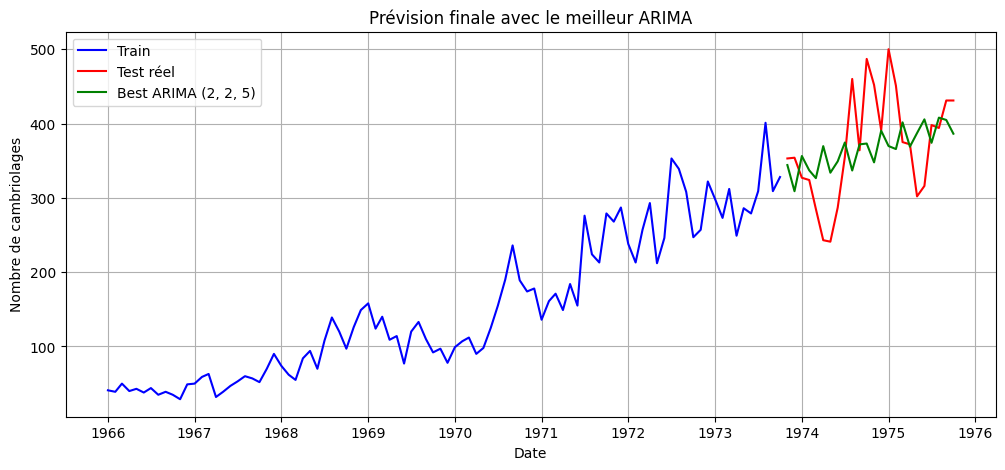

In [29]:
# ============================================================
# 19. VISUALISATION FINALE
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label="Train", color="blue")
plt.plot(test.index, test.values, label="Test réel", color="red")
plt.plot(test.index, pred_best_arima, label=f"Best ARIMA {best_order_aic}", color="green")
plt.title("Prévision finale avec le meilleur ARIMA")
plt.xlabel("Date")
plt.ylabel("Nombre de cambriolages")
plt.legend()
plt.grid()
plt.show()


# 25. Walk-forward validation ARIMA

La validation walk-forward est une méthode adaptée aux séries temporelles.

Son principe est le suivant :

1. entraîner le modèle sur une partie historique ;
2. prédire l’observation suivante ;
3. ajouter cette observation réelle à l’historique ;
4. répéter le processus jusqu’à la fin de la période de test.

Cette méthode respecte l’ordre chronologique des données.

Elle permet de simuler une situation réelle où l’on prédit le futur à partir des données disponibles dans le passé.


WALK-FORWARD VALIDATION


c:\Users\NITRO V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\NITRO V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\NITRO V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\NITRO V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum 

RMSE Walk-forward : 59.526541116796075
MAE Walk-forward : 47.95292040136957

Walk-forward Best ARIMA
MSE  : 3543.409097329614
RMSE : 59.526541116796075
MAE  : 47.95292040136957
AIC  : nan
BIC  : nan


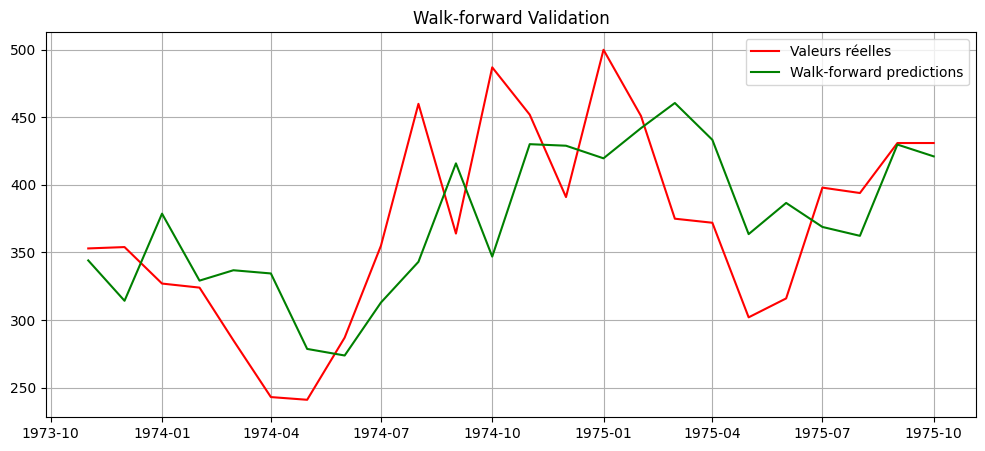

In [30]:
# ============================================================
# 18. WALK-FORWARD VALIDATION ARIMA
# ============================================================

print("\n==============================")
print("WALK-FORWARD VALIDATION")
print("==============================")

history = list(train.values)
walk_predictions = []

for t in range(len(test)):
    model = ARIMA(history, order=best_order_aic).fit()
    yhat = model.forecast()[0]
    walk_predictions.append(yhat)
    history.append(test.iloc[t])

rmse_walk = rmse_manual(test, walk_predictions)
mae_walk = mae_manual(test, walk_predictions)

print("RMSE Walk-forward :", rmse_walk)
print("MAE Walk-forward :", mae_walk)

evaluate_model("Walk-forward Best ARIMA", test, walk_predictions)

plt.figure(figsize=(12, 5))
plt.plot(test.index, test.values, label="Valeurs réelles", color="red")
plt.plot(test.index, walk_predictions, label="Walk-forward predictions", color="green")
plt.title("Walk-forward Validation")
plt.legend()
plt.grid()
plt.show()


# Risques méthodologiques : data leakage et surapprentissage

Dans les séries temporelles, deux risques importants doivent être évités.

## Data leakage

Le data leakage apparaît lorsqu’une information du futur est utilisée pendant l’entraînement.

Cela donne des performances artificiellement bonnes mais irréalistes.

Pour l’éviter, on respecte strictement l’ordre chronologique dans le découpage train/test et dans la validation walk-forward.

## Surapprentissage

Le surapprentissage apparaît lorsqu’un modèle apprend trop précisément les données d’entraînement mais généralise mal sur les données de test.

Pour le détecter, on compare les performances entre l’entraînement et le test, et on évite les modèles trop complexes.

# 26. Diagnostic des résidus

Après avoir choisi le meilleur modèle, il faut analyser ses résidus.

Les résidus sont définis par :

$$
e_t = y_t - \hat{y}_t
$$

Un bon modèle doit produire des résidus proches d’un bruit blanc, c’est-à-dire :

- sans autocorrélation significative ;
- centrés autour de zéro ;
- avec une variance relativement constante ;
- sans structure temporelle visible.

Dans cette partie, on utilise notamment le test de Ljung-Box et des graphiques de diagnostic.


Meilleur modèle selon RMSE : Naïf


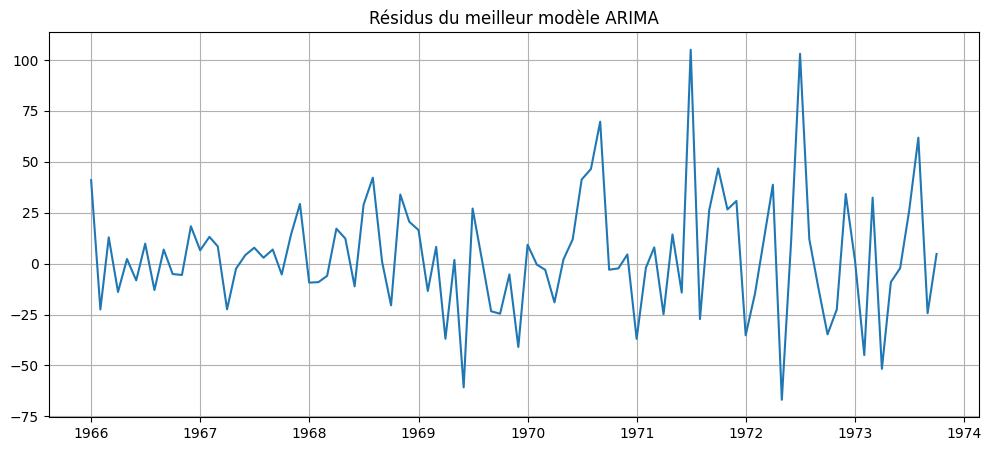

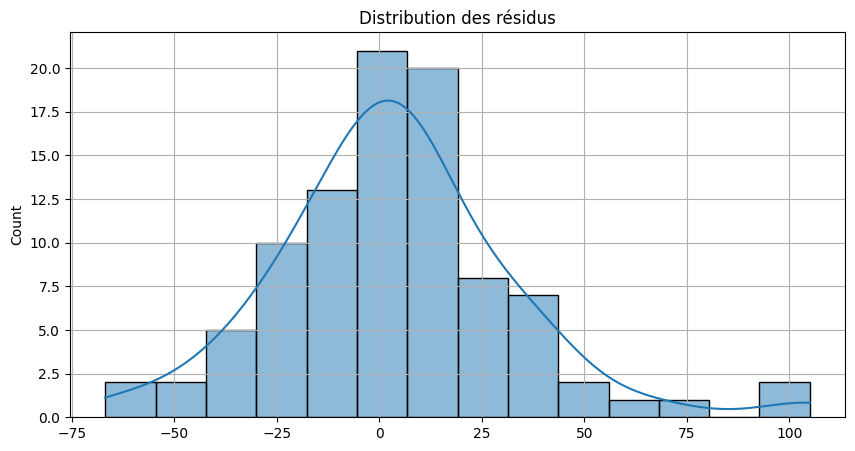

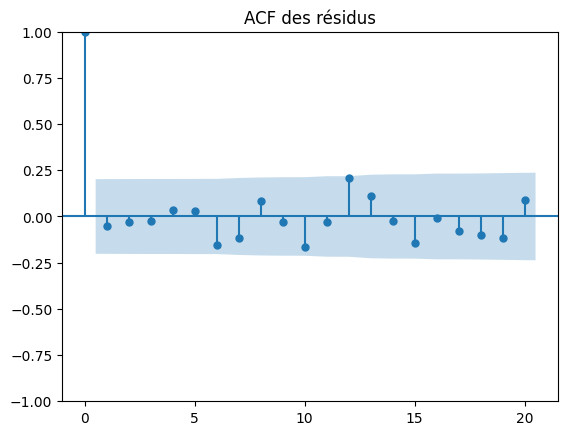

In [31]:
# ============================================================
# 20. DIAGNOSTIC DES RÉSIDUS DU MEILLEUR MODÈLE
# ============================================================

best_final_name = results_df.iloc[0]["Modèle"]
print("\nMeilleur modèle selon RMSE :", best_final_name)

# On prend le meilleur modèle ARIMA trouvé pour diagnostic
residuals = best_model_aic.resid

plt.figure(figsize=(12, 5))
plt.plot(residuals)
plt.title("Résidus du meilleur modèle ARIMA")
plt.grid()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True)
plt.title("Distribution des résidus")
plt.grid()
plt.show()

plot_acf(residuals.dropna(), lags=20)
plt.title("ACF des résidus")
plt.show()


Le test de Ljung-Box permet de vérifier si les résidus sont autocorrélés.

Hypothèses :

- $H_0$ : les résidus ne sont pas autocorrélés ;
- $H_1$ : les résidus sont autocorrélés.

La statistique du test est :

$$
Q = n(n+2)\sum_{k=1}^{h}\frac{\hat{\rho}_k^2}{n-k}
$$

où :

- $n$ est le nombre d’observations ;
- $h$ est le nombre de retards testés ;
- $\hat{\rho}_k$ est l’autocorrélation des résidus au retard $k$.

Si la p-value est inférieure à 0,05, on rejette $H_0$ et les résidus présentent encore une structure temporelle non expliquée.

In [32]:
print("\nTest Ljung-Box :")
ljung = acorr_ljungbox(residuals.dropna(), lags=[10], return_df=True)
print(ljung)

print("\nTest Shapiro-Wilk pour normalité :")
shapiro_test = shapiro(residuals.dropna())
print("Statistic :", shapiro_test.statistic)
print("p-value :", shapiro_test.pvalue)

print("\nTest ARCH pour homoscédasticité :")
arch_test = het_arch(residuals.dropna())
print("LM Statistic :", arch_test[0])
print("p-value :", arch_test[1])


Test Ljung-Box :
     lb_stat  lb_pvalue
10  8.394279   0.590383

Test Shapiro-Wilk pour normalité :
Statistic : 0.9583304518079345
p-value : 0.004425217256406653

Test ARCH pour homoscédasticité :
LM Statistic : 11.150210123068067
p-value : 0.3459356854199481


On complète le diagnostic du modèle en étudiant la distribution des résidus.

On vérifie notamment :

- si les résidus sont approximativement normaux ;
- si leur moyenne est proche de zéro ;
- si leur variance est stable dans le temps ;
- s’il existe des valeurs extrêmes ;
- si une structure reste visible dans les erreurs.

Une forte non-normalité ou une variance instable peut indiquer que le modèle ne capture pas toute la dynamique de la série.

# 27. Visualisation finale du meilleur modèle

Le choix du modèle final ne doit pas se baser uniquement sur une seule métrique.

On combine plusieurs critères :

- les performances sur l’ensemble de test ;
- les résultats de la walk-forward validation ;
- les valeurs de AIC et BIC ;
- la simplicité du modèle ;
- l’interprétabilité des paramètres ;
- le diagnostic des résidus.

Le modèle retenu est celui qui offre le meilleur compromis entre précision, stabilité et interprétabilité.

On représente maintenant les prédictions du meilleur modèle retenu face aux valeurs réelles.

Cette visualisation permet de juger concrètement la qualité du modèle.

On observe si le modèle :

- suit correctement l’évolution générale des braquages ;
- anticipe les hausses ou les baisses ;
- commet des erreurs importantes sur certaines périodes ;
- reste cohérent avec la dynamique globale de la série.

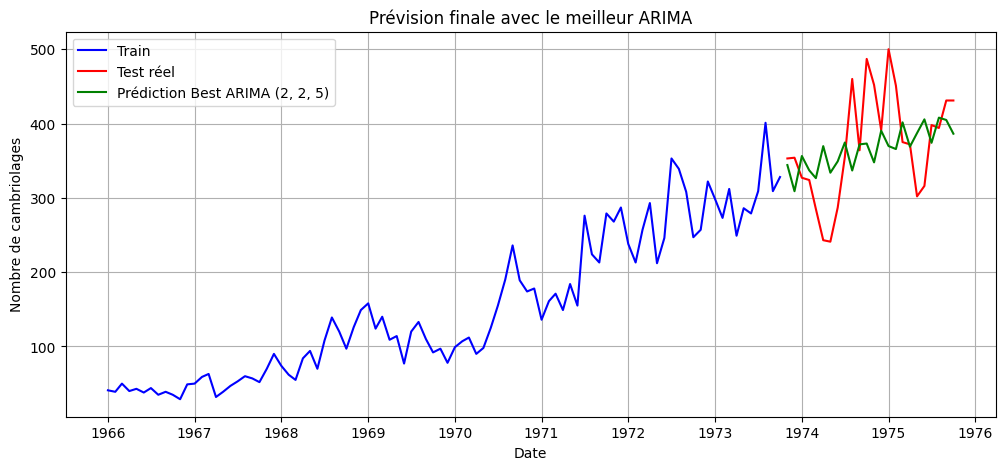

In [33]:
# ============================================================
# 21. VISUALISATION FINALE DES PRÉDICTIONS
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label="Train", color="blue")
plt.plot(test.index, test.values, label="Test réel", color="red")
plt.plot(test.index, pred_best_arima, label=f"Prédiction Best ARIMA {best_order_aic}", color="green")
plt.title("Prévision finale avec le meilleur ARIMA")
plt.xlabel("Date")
plt.ylabel("Nombre de cambriolages")
plt.legend()
plt.grid()
plt.show()


# 28. Conclusion générale

Cette dernière partie résume les principaux résultats du projet.

Elle doit rappeler :

- le comportement global de la série ;
- les transformations appliquées ;
- les modèles testés ;
- le modèle final retenu ;
- les performances obtenues ;
- les limites du travail ;
- les améliorations possibles.

Dans le contexte des braquages armés à Boston, l’objectif est d’interpréter ce que le modèle révèle sur la dynamique temporelle du phénomène.

In [34]:
# ============================================================
# 22. CONCLUSION AUTOMATIQUE
# ============================================================

print("\n==============================")
print("CONCLUSION")
print("==============================")

print("""
La série des cambriolages armés mensuels à Boston présente une tendance haussière claire.
L'analyse exploratoire montre une variance croissante et une distribution non parfaitement normale.
Les tests ADF et KPSS confirment que la série originale n'est pas stationnaire.

La différenciation d'ordre 1 permet de rendre la série plus stable.
Les graphiques ACF et PACF permettent une première identification des paramètres p et q.
Les baselines naïve et moyenne mobile servent de références minimales.

Plusieurs modèles ont été comparés : AR, MA, ARMA, ARIMA et SARIMA.
Le choix final doit être basé sur RMSE, MAE, AIC, BIC et le diagnostic des résidus.

Un bon modèle doit :
- battre les baselines ;
- avoir un RMSE faible ;
- avoir des résidus proches d'un bruit blanc ;
- éviter le surapprentissage ;
- rester interprétable dans le contexte métier.
""")



CONCLUSION

La série des cambriolages armés mensuels à Boston présente une tendance haussière claire.
L'analyse exploratoire montre une variance croissante et une distribution non parfaitement normale.
Les tests ADF et KPSS confirment que la série originale n'est pas stationnaire.

La différenciation d'ordre 1 permet de rendre la série plus stable.
Les graphiques ACF et PACF permettent une première identification des paramètres p et q.
Les baselines naïve et moyenne mobile servent de références minimales.

Plusieurs modèles ont été comparés : AR, MA, ARMA, ARIMA et SARIMA.
Le choix final doit être basé sur RMSE, MAE, AIC, BIC et le diagnostic des résidus.

Un bon modèle doit :
- battre les baselines ;
- avoir un RMSE faible ;
- avoir des résidus proches d'un bruit blanc ;
- éviter le surapprentissage ;
- rester interprétable dans le contexte métier.

